imports & config

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import networkx as nx
import osmnx as ox

from shapely.geometry import Point
from scipy import sparse
from scipy.sparse.csgraph import laplacian
from scipy.sparse.linalg import eigsh

from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)

### Por experimento, cambiar 'tec' a la carmpeta deseada 'tab' o 'cdmx'

In [2]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / 'data').exists():
            return p
    raise FileNotFoundError('Could not locate project root with data/raw and data/processed')

PROJECT_ROOT = find_project_root(Path.cwd())
RAW_DIR = PROJECT_ROOT / 'data' / 'industrial' / 'raw' # cambiar aqui dependiendo experimento
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'industrial' / 'processed'# cambiar aqui dependiendo experimento
FIG_DIR = PROJECT_ROOT / 'experimentos'  / 'industrial'  / 'outputs'/ 'figures'# cambiar aqui dependiendo experimento

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TEC_LAT, TEC_LON = 19.3617,  -99.2734
PROJ_EPSG = 32614

print('PROJECT_ROOT =', PROJECT_ROOT)
print('RAW_DIR =', RAW_DIR)

PROJECT_ROOT = /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026
RAW_DIR = /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/data/industrial/raw


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# EXPERIMENT CONFIGURATION
# To run on a different experiment, change EXPERIMENT below and update the
# paths inside EXPERIMENTS.  No other cell needs to be edited.
# Addresses Reviewer 2 & 3: centralises all parameters; grid-search justifies
# chosen values in Section §Sensitivity & Baselines.
# ══════════════════════════════════════════════════════════════════════════════
import random

EXPERIMENT = "student"   # Options: "student" | "industrial" | "city"

EXPERIMENTS = {
    "student": {
        "label": "Student Area — Tecnológico de Monterrey",
        "center_lat": 25.6516,
        "center_lon": -100.2895,
        "radius_km": 5.0,
    },
    "industrial": {
        "label": "Industrial Area",
        "center_lat": None,   # fill when data is ready
        "center_lon": None,
        "radius_km": 5.0,
    },
    "city": {
        "label": "Less-Developed City",
        "center_lat": None,
        "center_lon": None,
        "radius_km": 5.0,
    },
}

cfg = EXPERIMENTS[EXPERIMENT]

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
import numpy as _np_seed; _np_seed.random.seed(RANDOM_SEED)

# ── Spectral / affinity parameters ───────────────────────────────────────────
# Reviewer 3: K is justified by sensitivity sweep in §Sensitivity Analysis.
K_NEIGH_EUCLIDEAN = 12      # KNN for sparse affinity graph
MAX_K_EIGENGAP    = 20      # Upper limit for eigengap search
MIN_CLUSTER_SIZE  = 200     # Merge threshold

# ── MCA parameters ────────────────────────────────────────────────────────────
N_COMPONENTS_MCA  = 7

# ── Optimisation parameters ───────────────────────────────────────────────────
# Reviewer 2 & 3: default values chosen; grid search below produces the
# Pareto frontier that justifies these choices empirically.
D_MAX              = 366.0   # Service radius (m) — ~5 min walk at 1.2 m/s
S_MIN              = 240.0   # Minimum separation between candidates (m)
BETA               = 0.25    # MCA demand-weight blending coefficient
P_NEW_MODE         = "fixed" # "fixed" | "proportional" | "demand_weighted"
P_NEW_PER_CLUSTER  = 7       # Used when P_NEW_MODE == "fixed"
P_NEW_TOTAL        = 42      # Used when P_NEW_MODE in {"proportional","demand_weighted"}
PENALTY_UNCOVERED  = 5000.0  # Uncovered-demand penalty λ
TIME_LIMIT_SEC     = 300     # CBC solver time limit per cluster

print(f"Experiment : {EXPERIMENT} — {cfg['label']}")
print(f"Parameters : D_MAX={D_MAX}, S_MIN={S_MIN}, BETA={BETA}, "
      f"P_NEW_MODE={P_NEW_MODE}, P_NEW_PER_CLUSTER={P_NEW_PER_CLUSTER}, "
      f"PENALTY={PENALTY_UNCOVERED}, SEED={RANDOM_SEED}")


Experiment : student — Student Area — Tecnológico de Monterrey
Parameters : D_MAX=366.0, S_MIN=240.0, BETA=0.25, P_NEW_MODE=fixed, P_NEW_PER_CLUSTER=7, PENALTY=5000.0, SEED=42


In [4]:
manzanas_shp_path = RAW_DIR / 'INEGI_Manzanas_.shp'
manzanas_csv_path = RAW_DIR / 'INEGI_Manzanas_.csv'
oxxo_csv_path = RAW_DIR / 'INEGI_DENUE_cdmx.csv'

manzanas_geom = gpd.read_file(manzanas_shp_path)[['geometry']].copy()
manzanas_geom = manzanas_geom.set_crs('EPSG:4326', allow_override=True)

# Centroids in projected CRS, then back to lat/lon for robust coordinates
centroids_wgs84 = manzanas_geom.to_crs(epsg=PROJ_EPSG).centroid.to_crs(epsg=4326)
manzanas_geom['centroide'] = centroids_wgs84
manzanas_geom['lat'] = manzanas_geom['centroide'].y
manzanas_geom['lon'] = manzanas_geom['centroide'].x

manzanas_csv = pd.read_csv(manzanas_csv_path, encoding='latin1').copy()
manzanas_csv = manzanas_csv.iloc[:len(manzanas_geom)].copy()
manzanas_csv['geometry_poly'] = manzanas_geom['geometry'].values
manzanas_csv['centroide'] = manzanas_geom['centroide'].values
manzanas_csv['lat'] = manzanas_geom['lat'].values
manzanas_csv['lon'] = manzanas_geom['lon'].values

manzanas_csv[['lat', 'lon']].head()

,lat,lon
0,19.434990,-99.137565
1,19.428050,-99.204033
2,19.437544,-99.177701
3,19.426332,-99.148178
4,19.429246,-99.166395


In [5]:
# Keep study area: 5 km around Tec
gdf_points = gpd.GeoDataFrame(
    manzanas_csv.copy(),
    geometry=gpd.points_from_xy(manzanas_csv['lon'], manzanas_csv['lat']),
    crs='EPSG:4326'
)

tec_point_utm = gpd.GeoDataFrame(geometry=[Point(TEC_LON, TEC_LAT)], crs='EPSG:4326').to_crs(epsg=PROJ_EPSG)
study_poly_utm = tec_point_utm.buffer(5000).iloc[0]
study_poly_wgs84 = gpd.GeoSeries([study_poly_utm], crs=f'EPSG:{PROJ_EPSG}').to_crs(4326).iloc[0]

gdf_points_utm = gdf_points.to_crs(epsg=PROJ_EPSG)
mask_5km = gdf_points_utm.geometry.distance(tec_point_utm.geometry.iloc[0]) <= 5000
manzanas_completas = gdf_points.loc[mask_5km].copy()

print('Manzanas in 5km study area:', len(manzanas_completas))

Manzanas in 5km study area: 0


In [6]:
# Existing convenience stores (drop first 27 rows as in original workflow)
oxxo_coor = pd.read_csv(oxxo_csv_path, encoding='latin1').copy()
oxxo_coor = oxxo_coor.iloc[27:].copy()
oxxo_coor['lon'] = pd.to_numeric(oxxo_coor['Longitud'], errors='coerce')
oxxo_coor['lat'] = pd.to_numeric(oxxo_coor['Latitud'], errors='coerce')
oxxo_coor = oxxo_coor.dropna(subset=['lat', 'lon'])

gdf_oxxos = gpd.GeoDataFrame(
    oxxo_coor,
    geometry=gpd.points_from_xy(oxxo_coor['lon'], oxxo_coor['lat']),
    crs='EPSG:4326'
)

gdf_oxxos_utm = gdf_oxxos.to_crs(epsg=PROJ_EPSG)
oxxos_dentro_5km = gdf_oxxos_utm[gdf_oxxos_utm.geometry.within(study_poly_utm)].to_crs(4326).copy()

print('Existing stores inside 5km:', len(oxxos_dentro_5km))

Existing stores inside 5km: 0


shortest-path distance engine

In [7]:
graph_cache = PROCESSED_DIR / 'walk_graph_tec_5km.graphml'

if graph_cache.exists():
    G = ox.load_graphml(graph_cache)
    print('Graph loaded from cache:', graph_cache)
else:
    G = ox.graph_from_polygon(study_poly_wgs84, network_type='walk', simplify=True)
    ox.save_graphml(G, graph_cache)
    print('Graph downloaded and cached at:', graph_cache)

# Project graph to metric CRS for distance in meters
G_proj = ox.project_graph(G, to_crs=f'EPSG:{PROJ_EPSG}')
print('Graph nodes:', len(G_proj.nodes), 'edges:', len(G_proj.edges))

KeyboardInterrupt: 

In [ ]:
# Build node GeoDataFrame from manzanas and snap both sets to graph nodes
gdf_nodos = gpd.GeoDataFrame(
    manzanas_completas.copy(),
    geometry=gpd.points_from_xy(manzanas_completas['lon'], manzanas_completas['lat']),
    crs='EPSG:4326'
)
gdf_nodos_utm = gdf_nodos.to_crs(epsg=PROJ_EPSG).copy()

gdf_oxxos_utm = oxxos_dentro_5km.to_crs(epsg=PROJ_EPSG).copy()

nodo_graph_nodes = ox.distance.nearest_nodes(
    G_proj,
    X=gdf_nodos_utm.geometry.x.values,
    Y=gdf_nodos_utm.geometry.y.values
)
oxxo_graph_nodes = ox.distance.nearest_nodes(
    G_proj,
    X=gdf_oxxos_utm.geometry.x.values,
    Y=gdf_oxxos_utm.geometry.y.values
)

gdf_nodos['graph_node'] = nodo_graph_nodes
gdf_nodos_utm['graph_node'] = nodo_graph_nodes
gdf_oxxos_utm['graph_node'] = oxxo_graph_nodes

print('Snapped demand nodes:', len(gdf_nodos))
print('Snapped existing-store nodes:', len(gdf_oxxos_utm))

Snapped demand nodes: 2889
Snapped existing-store nodes: 23


In [ ]:
# Compute average nearest-neighbor distance among existing stores on the road network.
# Result is cached to disk — delete the cache file to force recomputation.

_cache_file = PROCESSED_DIR / 'avg_nn_m.json'

ox_nodes_unique = list(pd.unique(gdf_oxxos_utm['graph_node']))

if len(ox_nodes_unique) < 2:
    raise ValueError('Need at least 2 existing-store nodes in the study area to compute avg_nn_m')

if _cache_file.exists():
    import json as _json
    _cached = _json.loads(_cache_file.read_text())
    avg_nn_m = float(_cached['avg_nn_m'])
    print(f'avg_nn_m loaded from cache: {avg_nn_m:.2f} m  ({_cache_file})')
else:
    # O(N) single-source Dijkstra runs — one pass per store, then pick nearest other store.
    # Much faster than the O(N^2) pairwise approach for large N.
    nn_dists = []
    for _u in ox_nodes_unique:
        _lengths = nx.single_source_dijkstra_path_length(G_proj, _u, weight='length')
        _best = min(
            (_lengths[_v] for _v in ox_nodes_unique if _v != _u and _v in _lengths),
            default=np.inf
        )
        nn_dists.append(_best)

    nn_dists = np.array(nn_dists, dtype=float)
    finite_nn = nn_dists[np.isfinite(nn_dists)]
    if len(finite_nn) == 0:
        raise ValueError('No finite shortest paths among existing stores; network may be disconnected')

    avg_nn_m = float(finite_nn.mean())

    import json as _json
    _cache_file.write_text(_json.dumps({'avg_nn_m': avg_nn_m}))
    print(f'avg_nn_m computed and cached: {avg_nn_m:.2f} m  ({_cache_file})')


avg_nn_m loaded from cache: 1314.66 m  (/Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/data/industrial/processed/avg_nn_m.json)


In [ ]:
# Multi-source shortest path from all existing stores to all graph nodes
source_nodes = set(ox_nodes_unique)
network_dist_to_existing = nx.multi_source_dijkstra_path_length(
    G_proj,
    sources=source_nodes,
    weight='length'
)

gdf_nodos['distancia_red_m'] = gdf_nodos['graph_node'].map(lambda n: float(network_dist_to_existing.get(n, np.inf)))
gdf_nodos['es_candidato'] = gdf_nodos['distancia_red_m'] > avg_nn_m
gdf_nodos['oxxo_presente'] = gdf_nodos['graph_node'].isin(source_nodes)

manzanas_completas = manzanas_completas.copy()
manzanas_completas['distancia_red_m'] = gdf_nodos['distancia_red_m'].values
manzanas_completas['es_candidato'] = gdf_nodos['es_candidato'].values
manzanas_completas['oxxo_presente'] = gdf_nodos['oxxo_presente'].astype(int).values

finite_ratio = np.isfinite(gdf_nodos['distancia_red_m']).mean()
print('Finite network distance ratio:', round(100 * finite_ratio, 2), '%')
print('Candidate nodes:', int(gdf_nodos['es_candidato'].sum()), 'of', len(gdf_nodos))
print(gdf_nodos[['distancia_red_m', 'es_candidato']].describe(include='all'))

Finite network distance ratio: 100.0 %
Candidate nodes: 1521 of 2889
        distancia_red_m es_candidato
count       2889.000000         2889
unique              NaN            2
top                 NaN         True
freq                NaN         1521
mean        2073.359226          NaN
std         1806.707263          NaN
min            0.000000          NaN
25%          649.902247          NaN
50%         1411.273871          NaN
75%         3209.351513          NaN
max         9187.056787          NaN


Graph clustering with spectral + eigengap

In [ ]:
# Build sparse affinity matrix from network distances over k-nearest Euclidean neighbors
# K_NEIGH_EUCLIDEAN and MAX_K_EIGENGAP come from the EXPERIMENT CONFIGURATION cell.

coords_xy = np.column_stack([gdf_nodos_utm.geometry.x.values, gdf_nodos_utm.geometry.y.values])
n_nodes = coords_xy.shape[0]

nn = NearestNeighbors(n_neighbors=K_NEIGH_EUCLIDEAN + 1, metric='euclidean')
nn.fit(coords_xy)
_, idx_knn = nn.kneighbors(coords_xy)

rows, cols, dist_vals = [], [], []
sp_cache_nodes = {}

def sp_len_nodes(node_a, node_b):
    key = (node_a, node_b) if node_a <= node_b else (node_b, node_a)
    if key in sp_cache_nodes:
        return sp_cache_nodes[key]
    if node_a == node_b:
        sp_cache_nodes[key] = 0.0
        return 0.0
    try:
        d = float(nx.shortest_path_length(G_proj, source=node_a, target=node_b, weight='length'))
    except nx.NetworkXNoPath:
        d = np.inf
    sp_cache_nodes[key] = d
    return d

graph_nodes = gdf_nodos['graph_node'].to_numpy()
for i in range(n_nodes):
    for j in idx_knn[i, 1:]:
        if i >= j:
            continue
        d_ij = sp_len_nodes(graph_nodes[i], graph_nodes[j])
        if np.isfinite(d_ij):
            rows.extend([i, j])
            cols.extend([j, i])
            dist_vals.extend([d_ij, d_ij])

if len(dist_vals) == 0:
    raise ValueError('No finite pair distances found for affinity graph')

dist_vals = np.asarray(dist_vals, dtype=float)
sigma = np.median(dist_vals[dist_vals > 0]) if np.any(dist_vals > 0) else 1.0
aff_vals = np.exp(- (dist_vals ** 2) / (2.0 * sigma ** 2))

W = sparse.coo_matrix((aff_vals, (rows, cols)), shape=(n_nodes, n_nodes)).tocsr()
W = W.maximum(W.T)
W.setdiag(1.0)
W.eliminate_zeros()

print('Affinity matrix shape:', W.shape)
print('Affinity nnz:', W.nnz)
print('sigma used for Gaussian affinity:', round(float(sigma), 4))

Affinity matrix shape: (2889, 2889)
Affinity nnz: 37531
sigma used for Gaussian affinity: 270.1668


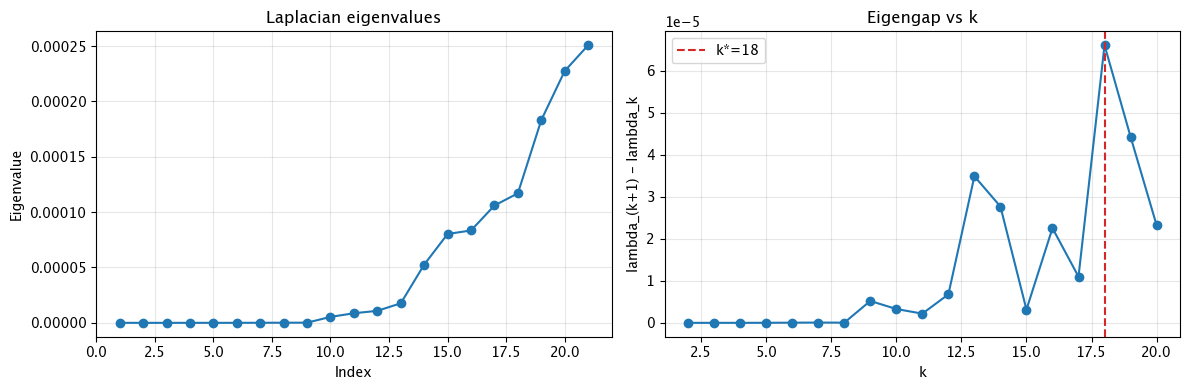

k_best_eigengap = 18
Figure saved to: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/spectral_eigengap_decision.png


In [ ]:
# Eigengap heuristic
L = laplacian(W, normed=True)

k_eigs = min(MAX_K_EIGENGAP + 1, n_nodes - 1)
if k_eigs < 3:
    raise ValueError('Not enough nodes to run eigengap analysis')

eigvals, eigvecs = eigsh(L, k=k_eigs, which='SM')
order = np.argsort(eigvals)
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

k_candidates = np.arange(2, min(MAX_K_EIGENGAP, len(eigvals) - 1) + 1)
gap_by_k = np.array([eigvals[k] - eigvals[k - 1] for k in k_candidates])
k_best_eigengap = int(k_candidates[np.argmax(gap_by_k)])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(np.arange(1, len(eigvals) + 1), eigvals, marker='o')
axes[0].set_title('Laplacian eigenvalues')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('Eigenvalue')
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_candidates, gap_by_k, marker='o')
axes[1].axvline(k_best_eigengap, linestyle='--', color='tab:red', label=f'k*={k_best_eigengap}')
axes[1].set_title('Eigengap vs k')
axes[1].set_xlabel('k')
axes[1].set_ylabel('lambda_(k+1) - lambda_k')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
out_path = FIG_DIR / 'spectral_eigengap_decision.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

print('k_best_eigengap =', k_best_eigengap)
print('Figure saved to:', out_path)

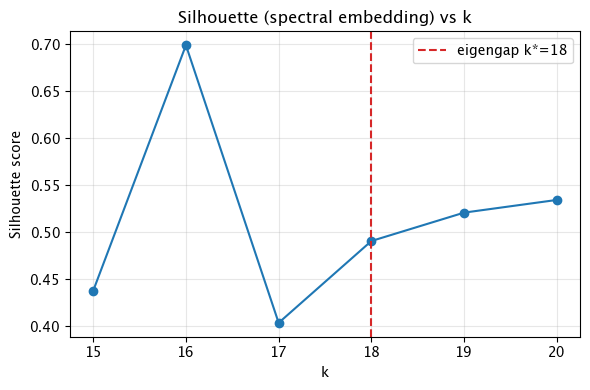

,k,silhouette_embedding
0,15,0.437805
1,16,0.698789
2,17,0.403673
3,18,0.490655
4,19,0.520834
5,20,0.534325


In [ ]:
# Additional decision support plot: silhouette in spectral-embedding space
# (supportive metric, while eigengap remains the primary selection criterion)

k_min = max(2, k_best_eigengap - 3)
k_max = min(MAX_K_EIGENGAP, k_best_eigengap + 3)
k_eval = list(range(k_min, k_max + 1))

embedding = eigvecs[:, 1:] if eigvecs.shape[1] > 1 else eigvecs
sil_scores = []

for k in k_eval:
    model_k = SpectralClustering(
        n_clusters=k,
        affinity='precomputed',
        assign_labels='kmeans',
        random_state=42,
        n_init=20
    )
    labels_k = model_k.fit_predict(W)
    dim = min(k, embedding.shape[1])
    sil = silhouette_score(embedding[:, :dim], labels_k, metric='euclidean')
    sil_scores.append(sil)

plt.figure(figsize=(6, 4))
plt.plot(k_eval, sil_scores, marker='o')
plt.axvline(k_best_eigengap, linestyle='--', color='tab:red', label=f'eigengap k*={k_best_eigengap}')
plt.title('Silhouette (spectral embedding) vs k')
plt.xlabel('k')
plt.ylabel('Silhouette score')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
out_path = FIG_DIR / 'spectral_silhouette_support.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()

pd.DataFrame({'k': k_eval, 'silhouette_embedding': sil_scores})

In [ ]:
# Final clustering with eigengap-selected k
model_final = SpectralClustering(
    n_clusters=k_best_eigengap,
    affinity='precomputed',
    assign_labels='kmeans',
    random_state=42,
    n_init=50
)
labels_final = model_final.fit_predict(W)

gdf_nodos['segmento'] = labels_final
manzanas_completas['segmento'] = labels_final

print('Final k (eigengap):', k_best_eigengap)
print(manzanas_completas['segmento'].value_counts().sort_index())

Final k (eigengap): 18
segmento
0       24
1     1141
2        2
3        6
4        3
5       12
6       17
7       81
8        6
9       29
10     908
11      88
12     194
13      46
14     207
15      40
16      33
17      52
Name: count, dtype: int64


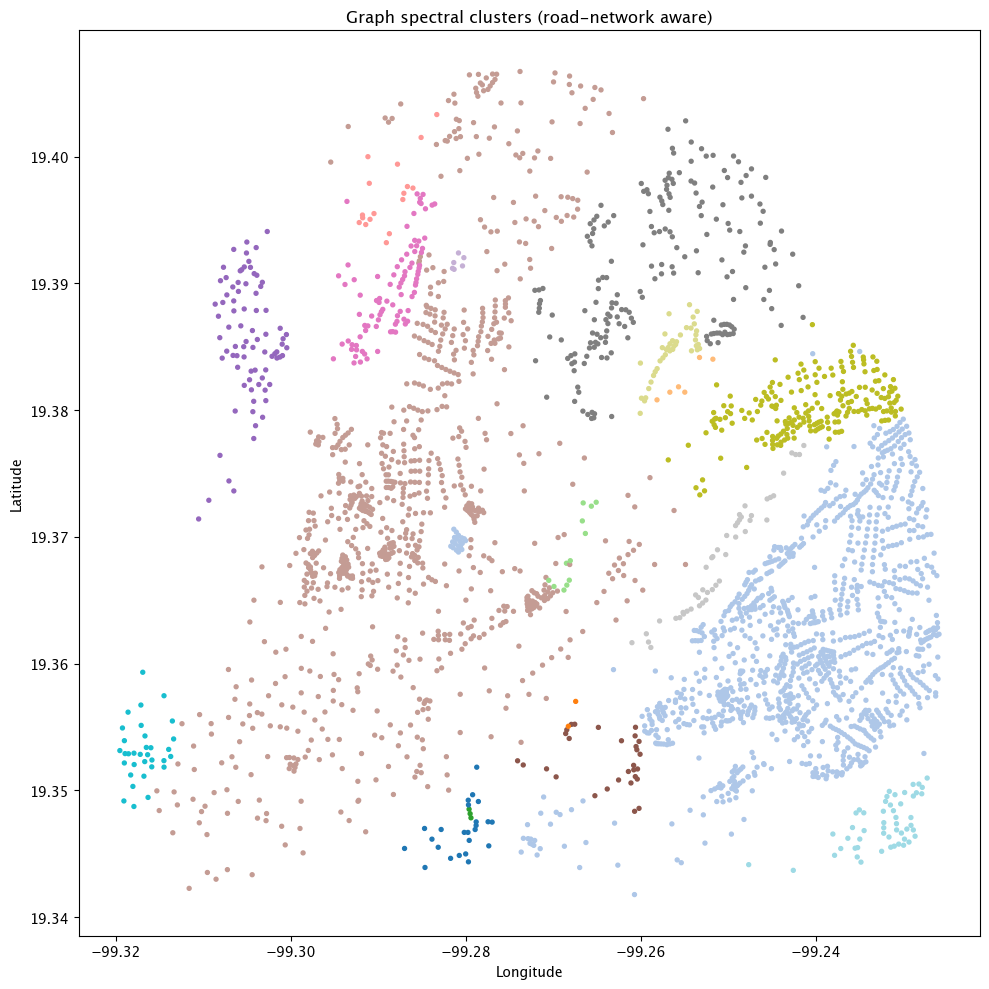

Figure saved to: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/graph_spectral_clusters_map.png


In [ ]:
# Cluster map (same structure style: lon/lat scatter + color by cluster)
plt.figure(figsize=(10, 10))
plt.scatter(
    manzanas_completas['lon'],
    manzanas_completas['lat'],
    c=manzanas_completas['segmento'],
    cmap='tab20',
    s=8
)
plt.title('Graph spectral clusters (road-network aware)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
out_path = FIG_DIR / 'graph_spectral_clusters_map.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', out_path)


Rule: raw spectral clusters with low demand share are merged into the nearest major demand territory.

Implementation details:
- Major clusters: clusters representing at least 5% of total demand.
- Small clusters: clusters representing less than 5% of total demand.
- Demand basis: total `POBTOT` by cluster.
- Closeness: shortest-path distance on the pedestrian road network from each small-cluster node to representative nodes of major clusters.
- Representative node of each major cluster: node closest to its demand-weighted spatial center in projected coordinates.
- Fallback: if no finite graph path is available, choose the closest major cluster by projected Euclidean distance to the major cluster center.

This replaces the previous fixed block-count rule (`n < 200`) with a demand-share rule, making the merge heuristic comparable across student, city, and industrial experiments.

In [ ]:
# Demand-based merge threshold.
# Prefer this over fixed MIN_CLUSTER_SIZE because block counts are not comparable
# across student/city/industrial experiments.

MIN_CLUSTER_DEMAND_SHARE = 0.05  # 5% of total demand

# Choose demand column
DEMAND_COL_FOR_MERGE = "POBTOT"

if DEMAND_COL_FOR_MERGE not in manzanas_completas.columns:
    raise ValueError(f"Missing demand column: {DEMAND_COL_FOR_MERGE}")

cluster_counts_before = manzanas_completas["segmento"].value_counts().sort_index()

cluster_demand_before = (
    manzanas_completas
    .groupby("segmento")[DEMAND_COL_FOR_MERGE]
    .sum()
    .sort_index()
)

total_demand_before = cluster_demand_before.sum()

if total_demand_before <= 0:
    raise ValueError("Total demand is zero; cannot apply demand-share merge heuristic.")

cluster_demand_share_before = cluster_demand_before / total_demand_before

major_clusters = cluster_demand_share_before[
    cluster_demand_share_before >= MIN_CLUSTER_DEMAND_SHARE
].index.tolist()

small_clusters = cluster_demand_share_before[
    cluster_demand_share_before < MIN_CLUSTER_DEMAND_SHARE
].index.tolist()

print("Cluster counts BEFORE merge:")
print(cluster_counts_before)

print("\nCluster demand BEFORE merge:")
print(cluster_demand_before)

print("\nCluster demand share BEFORE merge:")
print((cluster_demand_share_before * 100).round(2).astype(str) + "%")

print(f"\nMajor clusters (demand share >= {MIN_CLUSTER_DEMAND_SHARE:.1%}):", major_clusters)
print(f"Small clusters (demand share < {MIN_CLUSTER_DEMAND_SHARE:.1%}):", small_clusters)

if len(major_clusters) == 0:
    raise ValueError(
        f"No major clusters found; cannot apply merge heuristic with "
        f"MIN_CLUSTER_DEMAND_SHARE={MIN_CLUSTER_DEMAND_SHARE:.1%}"
    )

Cluster counts BEFORE merge:
segmento
0       24
1     1141
2        2
3        6
4        3
5       12
6       17
7       81
8        6
9       29
10     908
11      88
12     194
13      46
14     207
15      40
16      33
17      52
Name: count, dtype: int64

Cluster demand BEFORE merge:
segmento
0       4293
1     179105
2         36
3        610
4        288
5       1068
6       1734
7      12865
8        778
9       5849
10    133689
11     10931
12     28363
13      7152
14     27649
15      6322
16      4218
17      7064
Name: POBTOT, dtype: int64

Cluster demand share BEFORE merge:
segmento
0      0.99%
1     41.46%
2      0.01%
3      0.14%
4      0.07%
5      0.25%
6       0.4%
7      2.98%
8      0.18%
9      1.35%
10    30.95%
11     2.53%
12     6.57%
13     1.66%
14      6.4%
15     1.46%
16     0.98%
17     1.64%
Name: POBTOT, dtype: object

Major clusters (demand share >= 5.0%): [1, 10, 12, 14]
Small clusters (demand share < 5.0%): [0, 2, 3, 4, 5, 6, 7, 8, 9, 11, 13, 1

In [ ]:
# Prepare projected node table with cluster labels
gdf_nodos_utm = gdf_nodos_utm.copy()
gdf_nodos_utm['segmento'] = gdf_nodos['segmento'].values

# Major cluster centroids (projected XY)
major_centroids = (
    gdf_nodos_utm[gdf_nodos_utm['segmento'].isin(major_clusters)]
    .groupby('segmento')
    .agg(cx=('geometry', lambda s: s.x.mean()),
         cy=('geometry', lambda s: s.y.mean()))
)

# Representative graph node per major cluster (closest to major centroid)
major_rep_graph_node = {}
for c in major_clusters:
    sub = gdf_nodos_utm[gdf_nodos_utm['segmento'] == c].copy()
    cx, cy = major_centroids.loc[c, 'cx'], major_centroids.loc[c, 'cy']
    d2 = (sub.geometry.x - cx) ** 2 + (sub.geometry.y - cy) ** 2
    rep_idx = d2.idxmin()
    major_rep_graph_node[c] = int(sub.loc[rep_idx, 'graph_node'])

major_rep_graph_node

{1: 2335717681, 10: 8157148056, 12: 2336489567, 14: 5475642382}

In [ ]:
# Reassign each node from small clusters to closest major cluster by shortest-path distance
sp_cache_reassign = {}

def sp_len_cached(a, b):
    key = (a, b) if a <= b else (b, a)
    if key in sp_cache_reassign:
        return sp_cache_reassign[key]
    if a == b:
        sp_cache_reassign[key] = 0.0
        return 0.0
    try:
        d = float(nx.shortest_path_length(G_proj, source=a, target=b, weight='length'))
    except nx.NetworkXNoPath:
        d = np.inf
    sp_cache_reassign[key] = d
    return d

seg_merged = gdf_nodos_utm['segmento'].copy()
major_cxy = {c: (major_centroids.loc[c, 'cx'], major_centroids.loc[c, 'cy']) for c in major_clusters}

mask_small = gdf_nodos_utm['segmento'].isin(small_clusters)
idx_small = gdf_nodos_utm[mask_small].index.tolist()

for idx in idx_small:
    node_id = int(gdf_nodos_utm.loc[idx, 'graph_node'])

    best_c = None
    best_d = np.inf

    for c in major_clusters:
        d = sp_len_cached(node_id, major_rep_graph_node[c])
        if d < best_d:
            best_d = d
            best_c = c

    if np.isfinite(best_d):
        seg_merged.loc[idx] = best_c
    else:
        # fallback if disconnected: nearest major centroid in projected Euclidean space
        x0, y0 = gdf_nodos_utm.loc[idx, 'geometry'].x, gdf_nodos_utm.loc[idx, 'geometry'].y
        best_c_e = min(major_clusters, key=lambda c: (x0 - major_cxy[c][0])**2 + (y0 - major_cxy[c][1])**2)
        seg_merged.loc[idx] = best_c_e

# Optional relabel to contiguous ids sorted by descending size (for cleaner downstream reports)
counts_tmp = seg_merged.value_counts().sort_values(ascending=False)
new_label_map = {old_lbl: new_lbl for new_lbl, old_lbl in enumerate(counts_tmp.index.tolist())}
seg_merged_compact = seg_merged.map(new_label_map).astype(int)

# Update all relevant tables
gdf_nodos['segmento_original'] = gdf_nodos['segmento']
gdf_nodos_utm['segmento_original'] = gdf_nodos_utm['segmento']
manzanas_completas['segmento_original'] = manzanas_completas['segmento']

gdf_nodos['segmento'] = seg_merged_compact.values
gdf_nodos_utm['segmento'] = seg_merged_compact.values
manzanas_completas['segmento'] = seg_merged_compact.values

cluster_counts_after = manzanas_completas['segmento'].value_counts().sort_index()

print('Cluster counts AFTER merge/relabel:')
print(cluster_counts_after)
print('Final number of clusters:', cluster_counts_after.shape[0])
print('Label map old->new:')
print(new_label_map)

Cluster counts AFTER merge/relabel:
segmento
0    1199
1    1189
2     261
3     240
Name: count, dtype: int64
Final number of clusters: 4
Label map old->new:
{1: 0, 10: 1, 14: 2, 12: 3}


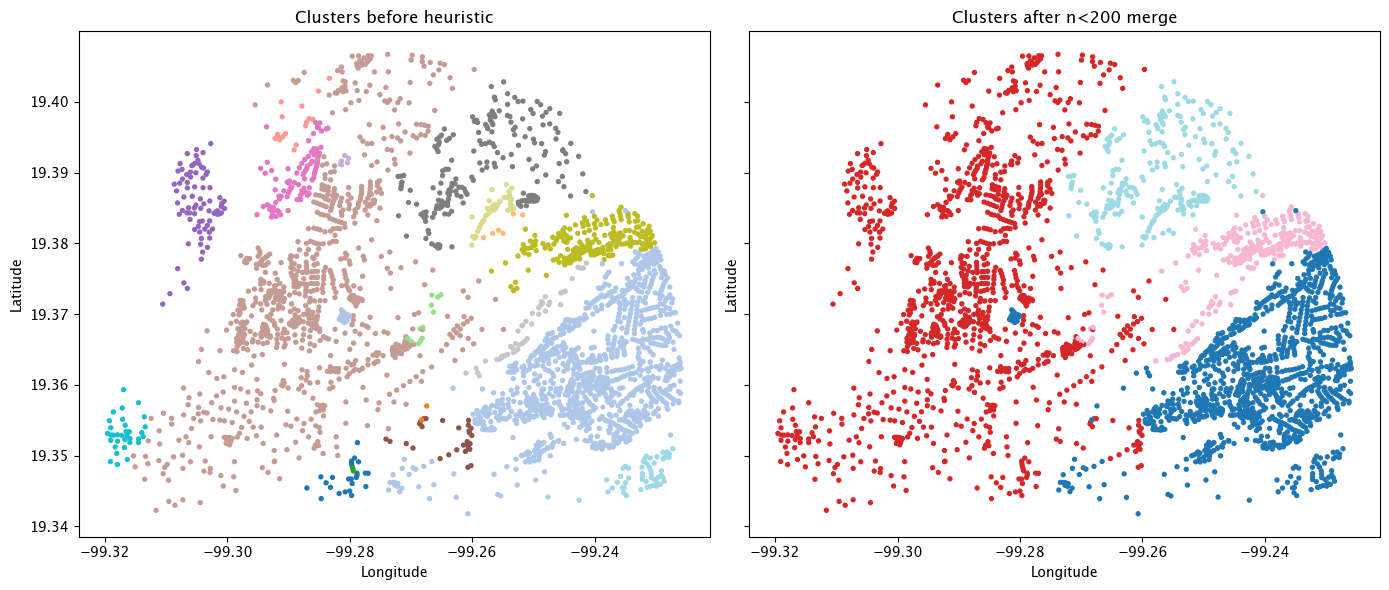

Figure saved to: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/graph_spectral_clusters_before_after_merge.png


In [ ]:
# Before vs after figure (same style as cluster scatter map)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

axes[0].scatter(
    manzanas_completas['lon'],
    manzanas_completas['lat'],
    c=manzanas_completas['segmento_original'],
    cmap='tab20',
    s=8
)
axes[0].set_title('Clusters before heuristic')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')

axes[1].scatter(
    manzanas_completas['lon'],
    manzanas_completas['lat'],
    c=manzanas_completas['segmento'],
    cmap='tab20',
    s=8
)
axes[1].set_title('Clusters after n<200 merge')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')

plt.tight_layout()
out_path = FIG_DIR / 'graph_spectral_clusters_before_after_merge.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', out_path)

 MCA (categorical multivariate analysis)

We now use MCA to build a socio-urban composite index from categorical versions of the indicators.

Compatibility decision for downstream cells:
- `MCA1` is the first MCA axis score.
- We use `MCA1` as the main socio-urban score in downstream modeling.

In [ ]:
import prince

cols_mca = [
    'POB0_14_P', 'P15A29A_P', 'P30A59A_P',
    'P_60YMAS_P', 'P_CD_P', 'GRAPROES',
    'VIVPAR_P', 'TVIPAHAB', 'TVIPAHAB_P',
    'VIVNOHAB_P', 'PRO_OCUP_C',
    'V3MASOCU_P', 'VPH_PIDT_P', 'VPH_C_EL_P',
    'VPH_EXSA_P', 'VPH_DREN_P', 'RECUCALL_C',
    'RAMPAS_C', 'PASOPEAT_C', 'BANQUETA_C', 'GUARNICI_C', 'CICLOVIA_C',
    'CICLOCAR_C', 'ALUMPUB_C', 'LETRERO_C', 'TELPUB_C', 'ARBOLES_C',
    'DRENAJEP_C', 'TRANSCOL_C', 'ACESOPER_C', 'ACESOAUT_C', 'PUESSEMI_C',
    'PUESAMBU_C'
]

missing_cols = [c for c in cols_mca if c not in manzanas_completas.columns]
if missing_cols:
    raise ValueError(f'Missing columns for MCA: {missing_cols}')

X_mca_base = manzanas_completas[cols_mca].copy()
print('X_mca_base shape:', X_mca_base.shape)
X_mca_base.head(3)

X_mca_base shape: (2889, 33)


,POB0_14_P,P15A29A_P,P30A59A_P,P_60YMAS_P,P_CD_P,GRAPROES,VIVPAR_P,TVIPAHAB,TVIPAHAB_P,VIVNOHAB_P,PRO_OCUP_C,V3MASOCU_P,VPH_PIDT_P,VPH_C_EL_P,VPH_EXSA_P,VPH_DREN_P,RECUCALL_C,RAMPAS_C,PASOPEAT_C,BANQUETA_C,GUARNICI_C,CICLOVIA_C,CICLOCAR_C,ALUMPUB_C,LETRERO_C,TELPUB_C,ARBOLES_C,DRENAJEP_C,TRANSCOL_C,ACESOPER_C,ACESOAUT_C,PUESSEMI_C,PUESAMBU_C
9,16.56,22.52,37.09,23.84,13.25,10.26,100.0,38,95.00,5.00,0.97,2.63,100.0,100.0,100.0,100.0,1,3,3,1,1,3,3,2,2,2,2,3,3,3,3,3,3
12,3.39,16.95,44.07,35.59,10.17,12.07,100.0,26,83.87,16.13,0.57,0.00,100.0,100.0,100.0,100.0,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
15,13.62,16.35,55.31,14.71,3.81,15.73,100.0,154,93.90,6.10,0.56,0.00,100.0,100.0,100.0,100.0,1,2,1,1,1,3,3,2,1,2,2,1,3,1,1,3,3


In [ ]:
# Intermediate check: missingness and cardinality before categorization
summary_mca = pd.DataFrame({
    'missing_pct': X_mca_base.isna().mean() * 100,
    'n_unique': X_mca_base.nunique(dropna=True)
}).sort_values(['missing_pct', 'n_unique'], ascending=[False, False])
summary_mca.head(15)

,missing_pct,n_unique
P_60YMAS_P,0.0,1335
POB0_14_P,0.0,1241
P30A59A_P,0.0,1228
P15A29A_P,0.0,1184
GRAPROES,0.0,804
P_CD_P,0.0,759
TVIPAHAB_P,0.0,718
VIVNOHAB_P,0.0,686
V3MASOCU_P,0.0,316
TVIPAHAB,0.0,264


In [ ]:
def to_mca_category(series: pd.Series, q: int = 5) -> pd.Series:
    x = pd.to_numeric(series, errors='coerce')

    miss = x.isna()
    n_unique = x.nunique(dropna=True)

    if n_unique == 0:
        out = pd.Series('MISSING', index=series.index, dtype='object')
        return out

    if n_unique <= q:
        out = x.round(6).astype('string')
        out[miss] = 'MISSING'
        return out.astype('category')

    try:
        binned = pd.qcut(x, q=q, duplicates='drop')
        out = binned.astype('string')
    except Exception:
        binned = pd.cut(x, bins=min(q, max(2, n_unique)), duplicates='drop')
        out = binned.astype('string')

    out[miss] = 'MISSING'
    return out.astype('category')

X_mca_cat = pd.DataFrame({c: to_mca_category(X_mca_base[c], q=5) for c in cols_mca})

print('Categorized matrix shape:', X_mca_cat.shape)
print('Example categories counts (first 5 vars):')
for c in cols_mca[:5]:
    print(c, '->', X_mca_cat[c].nunique())

# Prince compatibility: explicitly build dense numeric one-hot matrix
# to avoid sparse/object dtype issues across scipy/pandas versions.
X_mca_ready = pd.get_dummies(X_mca_cat.astype(str), drop_first=False, dtype=float)
print('One-hot MCA matrix shape:', X_mca_ready.shape)
print('One-hot dtypes unique:', pd.Series(X_mca_ready.dtypes.astype(str)).value_counts().to_dict())

X_mca_cat.head(3)


Categorized matrix shape: (2889, 33)
Example categories counts (first 5 vars):
POB0_14_P -> 5
P15A29A_P -> 5
P30A59A_P -> 5
P_60YMAS_P -> 5
P_CD_P -> 5
One-hot MCA matrix shape: (2889, 103)
One-hot dtypes unique: {'float64': 103}


,POB0_14_P,P15A29A_P,P30A59A_P,P_60YMAS_P,P_CD_P,GRAPROES,VIVPAR_P,TVIPAHAB,TVIPAHAB_P,VIVNOHAB_P,PRO_OCUP_C,V3MASOCU_P,VPH_PIDT_P,VPH_C_EL_P,VPH_EXSA_P,VPH_DREN_P,RECUCALL_C,RAMPAS_C,PASOPEAT_C,BANQUETA_C,GUARNICI_C,CICLOVIA_C,CICLOCAR_C,ALUMPUB_C,LETRERO_C,TELPUB_C,ARBOLES_C,DRENAJEP_C,TRANSCOL_C,ACESOPER_C,ACESOAUT_C,PUESSEMI_C,PUESAMBU_C
9,"(13.122, 17.14]","(19.292, 22.67]","(36.26, 40.66]","(18.386, 24.07]","(7.148, 44.83]","(9.27, 10.63]","(-1.001, 100.0]","(22.0, 38.0]","(93.75, 99.034]","(4.17, 8.33]","(0.81, 1.0]","(0.0, 4.0]","(99.506, 100.0]","(-1.001, 100.0]","(-1.001, 100.0]","(-1.001, 100.0]","(0.999, 2.0]","(2.0, 3.0]","(2.0, 3.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 3.0]","(0.999, 3.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(2.0, 3.0]","(2.0, 3.0]","(0.999, 3.0]","(0.999, 3.0]","(0.999, 3.0]","(0.999, 3.0]"
12,"(-1.001, 8.33]","(14.29, 19.292]","(43.688, 48.084]","(24.07, 70.0]","(7.148, 44.83]","(10.63, 12.318]","(-1.001, 100.0]","(22.0, 38.0]","(80.0, 89.47]","(14.29, 84.0]","(0.51, 0.64]","(-1.001, 0.0]","(99.506, 100.0]","(-1.001, 100.0]","(-1.001, 100.0]","(-1.001, 100.0]","(2.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]","(3.0, 9.0]"
15,"(13.122, 17.14]","(14.29, 19.292]","(48.084, 100.0]","(13.602, 18.386]","(2.7, 4.76]","(14.23, 17.6]","(-1.001, 100.0]","(67.0, 1376.0]","(93.75, 99.034]","(4.17, 8.33]","(0.51, 0.64]","(-1.001, 0.0]","(99.506, 100.0]","(-1.001, 100.0]","(-1.001, 100.0]","(-1.001, 100.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 3.0]","(0.999, 3.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(0.999, 2.0]","(2.0, 3.0]","(0.999, 3.0]","(0.999, 3.0]","(0.999, 3.0]","(0.999, 3.0]"


In [ ]:
# Fit MCA
n_components_mca = 7
mca = prince.MCA(
    n_components=n_components_mca,
    n_iter=10,
    copy=True,
    check_input=True,
    one_hot=False,
    random_state=42
)

Z_mca = mca.fit_transform(X_mca_ready)
Z_mca.columns = [f'MCA{i+1}' for i in range(Z_mca.shape[1])]

print('MCA scores shape:', Z_mca.shape)
Z_mca.head(3)


MCA scores shape: (2889, 7)


,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7
9,-0.391395,-0.303481,0.371636,-0.249399,0.217028,-0.257988,0.118354
12,1.569111,-0.215327,-0.114864,0.238009,0.046927,0.145408,-0.043641
15,-0.314293,-0.473214,-0.347554,0.045082,-0.310802,-0.347348,0.242519


In [ ]:
# Extract explained inertia / variance-style summary (version-robust)
if hasattr(mca, 'percentage_of_variance_') and mca.percentage_of_variance_ is not None:
    explained = np.array(mca.percentage_of_variance_, dtype=float)
    if explained.max() > 1.0:
        explained = explained / 100.0
elif hasattr(mca, 'eigenvalues_') and mca.eigenvalues_ is not None:
    ev = np.array(mca.eigenvalues_, dtype=float)
    explained = ev / ev.sum() if ev.sum() > 0 else ev
else:
    explained = np.repeat(np.nan, Z_mca.shape[1])

cum_explained = np.nancumsum(explained)

print('Explained (first components):')
print(np.round(explained, 4))
print('Cumulative explained:')
print(np.round(cum_explained, 4))

# ── Greenacre correction ────────────────────────────────────────────────────
# Raw MCA inertia is inflated by the number of categories (total_inertia = K/Q - 1).
# The Benzecri/Greenacre correction produces percentages comparable to PCA.
_ev_raw = np.array(mca.eigenvalues_, dtype=float) if hasattr(mca, 'eigenvalues_') else np.array([])
if len(_ev_raw) > 0:
    _Q = len(cols_mca)            # number of original variables after removing absolutes
    _ev_corr = (((_Q / (_Q - 1)) * (_ev_raw - 1.0 / _Q)) ** 2)
    _ev_corr[_ev_raw < 1.0 / _Q] = 0.0
    _total_corr = _ev_corr.sum()
    gc_explained = _ev_corr / _total_corr if _total_corr > 0 else np.zeros_like(_ev_corr)
    print('Greenacre-corrected explained inertia (first components):')
    print(np.round(gc_explained, 4))
    print('Greenacre cumulative:')
    print(np.round(np.cumsum(gc_explained), 4))
else:
    print('eigenvalues_ not available; skipping Greenacre correction')

Explained (first components):
[0.2473 0.0787 0.0701 0.0335 0.0263 0.0244 0.0232]
Cumulative explained:
[0.2473 0.326  0.3962 0.4296 0.456  0.4803 0.5035]
Greenacre-corrected explained inertia (first components):
[0.8721 0.0667 0.0501 0.0059 0.0023 0.0016 0.0013]
Greenacre cumulative:
[0.8721 0.9388 0.9888 0.9948 0.9971 0.9987 1.    ]


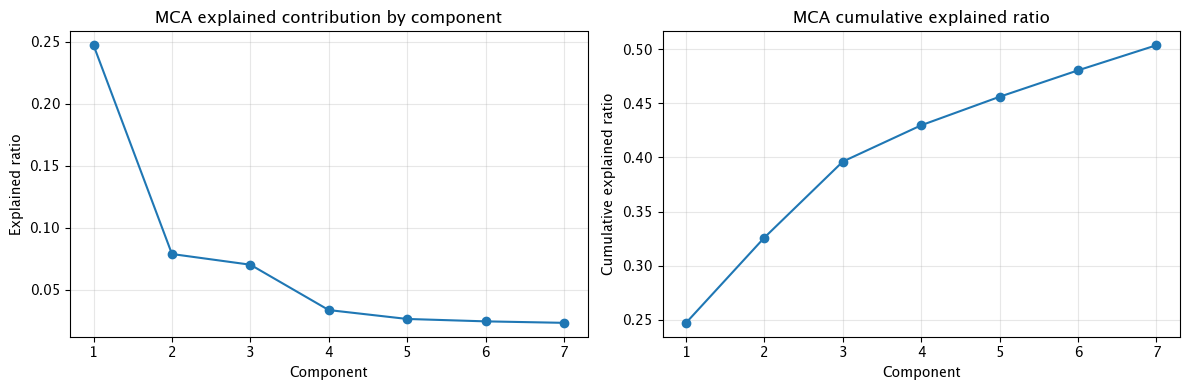

Figure saved to: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/mca_explained_components.png


In [ ]:
# Decision-style plots for MCA components (analogous to PCA diagnostics)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(np.arange(1, len(explained) + 1), explained, marker='o')
axes[0].set_title('MCA explained contribution by component')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained ratio')
axes[0].grid(True, alpha=0.3)

axes[1].plot(np.arange(1, len(cum_explained) + 1), cum_explained, marker='o')
axes[1].set_title('MCA cumulative explained ratio')
axes[1].set_xlabel('Component')
axes[1].set_ylabel('Cumulative explained ratio')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
out_path = FIG_DIR / 'mca_explained_components.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', out_path)

In [ ]:
# Intermediate interpretation: top contributing variables to MCA1
# Prince returns contributions by one-hot levels; aggregate by original variable prefix.
col_contrib = mca.column_contributions_.copy()
col_contrib.columns = [f'MCA{i+1}' for i in range(col_contrib.shape[1])]

var_prefixes = sorted(cols_mca, key=len, reverse=True)

def original_var(level_name: str) -> str:
    s = str(level_name)
    for v in var_prefixes:
        if s.startswith(v):
            return v
    return s.split('_')[0]

col_contrib['variable'] = [original_var(ix) for ix in col_contrib.index]
var_contrib = col_contrib.groupby('variable').sum(numeric_only=True).sort_values('MCA1', ascending=False)

var_contrib.head(15)

,MCA1,MCA2,MCA3,MCA4,MCA5,MCA6,MCA7
variable,,,,,,,
RAMPAS_C,0.057607,0.018749,0.076565,0.001563,0.001178,0.002029,0.002392
PASOPEAT_C,0.057599,0.006866,0.056197,0.012286,0.000726,0.003944,0.001010
DRENAJEP_C,0.057594,0.015348,0.037328,0.010484,0.000066,0.000829,0.000180
ARBOLES_C,0.057591,0.013552,0.029849,0.035162,0.001271,0.003013,0.044251
LETRERO_C,0.057590,0.023939,0.024312,0.017607,0.004268,0.000491,0.002075
BANQUETA_C,0.057589,0.013480,0.030559,0.100828,0.010059,0.002579,0.179328
GUARNICI_C,0.057589,0.011660,0.031658,0.101643,0.013536,0.004832,0.168236
TRANSCOL_C,0.057589,0.001344,0.017623,0.037518,0.000088,0.018115,0.003502
TELPUB_C,0.057589,0.003568,0.013946,0.029398,0.001019,0.021457,0.009951


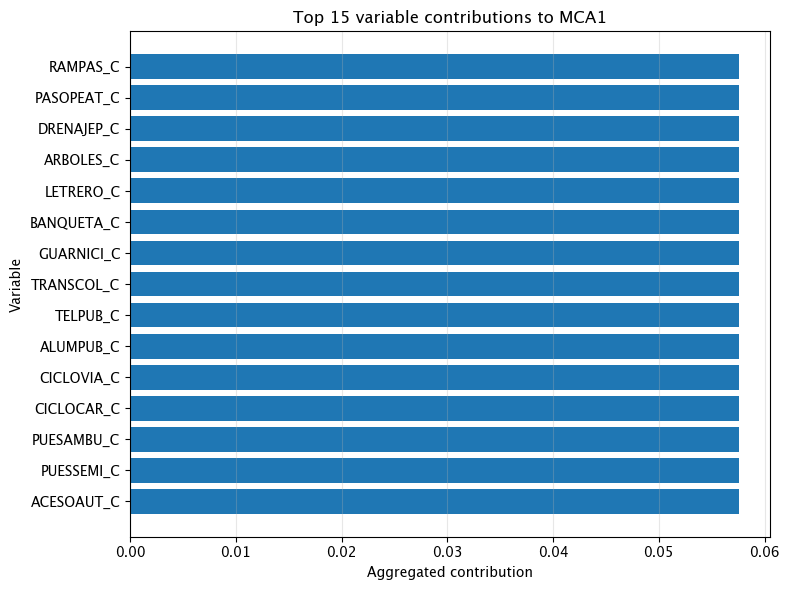

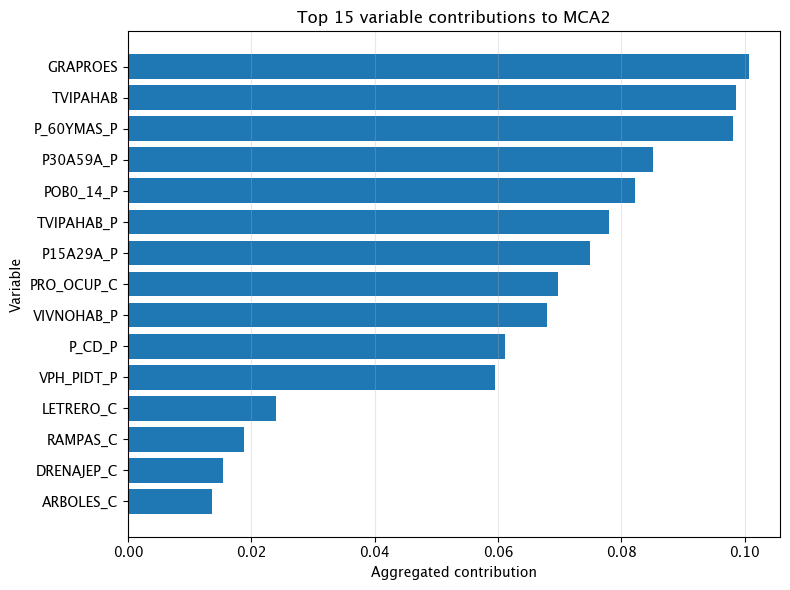

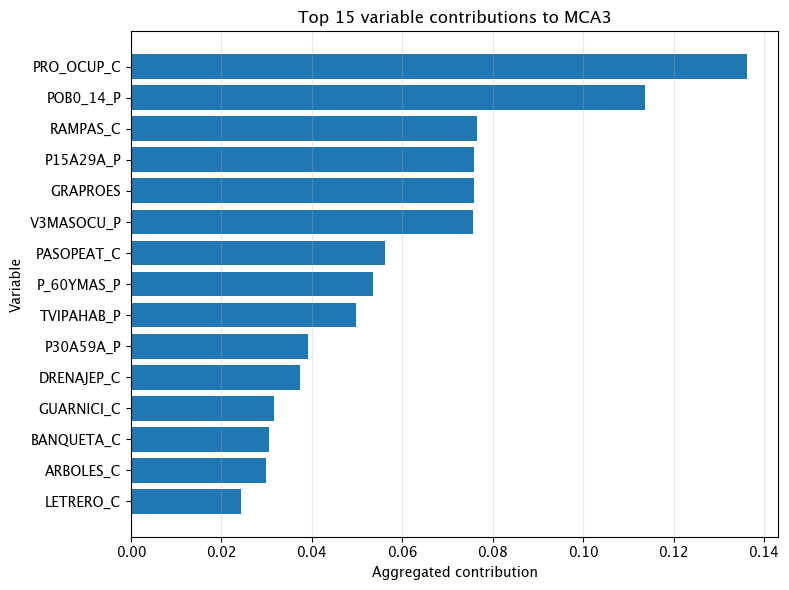

In [ ]:
import matplotlib.pyplot as plt

def plot_mca_variable_contributions(var_contrib, dims=("MCA1", "MCA2", "MCA3"), top_n=15, save_path=None):
    for dim in dims:
        top = var_contrib[dim].sort_values(ascending=False).head(top_n).sort_values()

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.barh(top.index, top.values)
        ax.set_title(f"Top {top_n} variable contributions to {dim}")
        ax.set_xlabel("Aggregated contribution")
        ax.set_ylabel("Variable")
        ax.grid(axis="x", alpha=0.3)

        plt.tight_layout()

        if save_path is not None:
            fig.savefig(save_path / f"mca_variable_contributions_{dim.lower()}.png", dpi=300, bbox_inches="tight")

        plt.show()

plot_mca_variable_contributions(
    var_contrib,
    dims=("MCA1", "MCA2", "MCA3"),
    top_n=15,
    #save_path=FIGURES_DIR
)

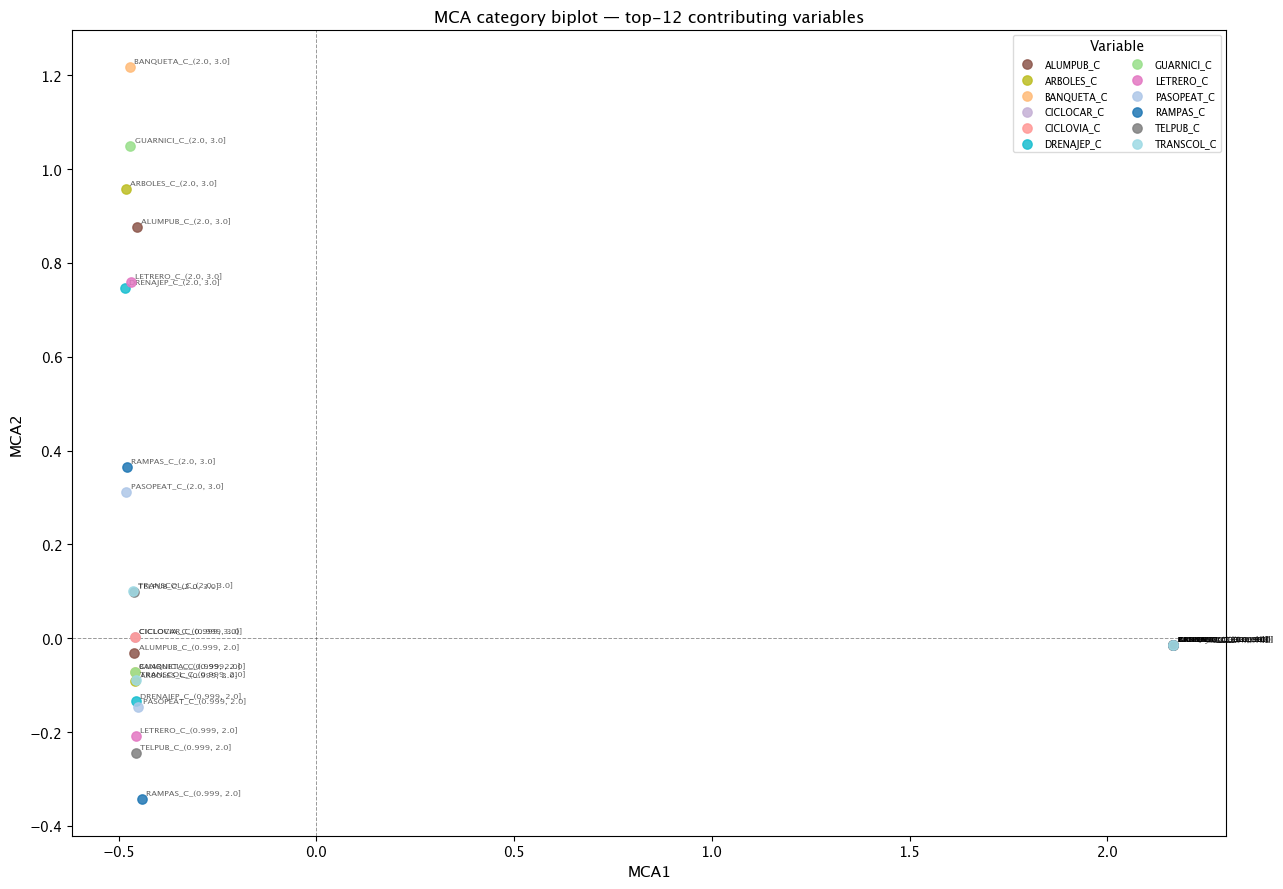

Biplot saved to: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/mca_category_biplot.png

Reading the biplot:
  Categories toward +MCA1 characterize HIGH-MCA1 neighborhoods.
  Categories toward -MCA1 characterize LOW-MCA1 neighborhoods.
  After sign correction (next cell), +MCA1 should = better urban conditions.


In [ ]:
# MCA category biplot — key interpretive plot
# Shows which category labels (variable levels) pull each axis.
# Positive MCA1 = the dominant socio-urban "direction" of that pole.

if hasattr(mca, 'column_coordinates_') and mca.column_coordinates_ is not None:
    _col_coords = mca.column_coordinates_.copy()
else:
    try:
        _col_coords = mca.column_coordinates(X_mca_ready).copy()
    except Exception as _e:
        raise AttributeError(f'Cannot retrieve column coordinates from MCA object: {_e}')

_col_coords.columns = [f'MCA{i+1}' for i in range(_col_coords.shape[1])]
_col_coords['variable'] = [original_var(ix) for ix in _col_coords.index]

# Restrict to top-12 contributing variables for readability
_top_vars_bp = var_contrib.head(12).index.tolist()
_coords_top = _col_coords[_col_coords['variable'].isin(_top_vars_bp)].copy()

_unique_vars = _coords_top['variable'].unique()
_cmap_bp = plt.cm.get_cmap('tab20', len(_unique_vars))
_color_map = {v: _cmap_bp(k) for k, v in enumerate(_unique_vars)}

fig, ax = plt.subplots(figsize=(13, 9))
for _var, _grp in _coords_top.groupby('variable'):
    ax.scatter(_grp['MCA1'], _grp['MCA2'], s=45, alpha=0.85,
               color=_color_map[_var], label=_var, zorder=3)
    for _lbl, _row in _grp.iterrows():
        _txt = str(_lbl)[-24:] if len(str(_lbl)) > 24 else str(_lbl)
        ax.annotate(_txt, (_row['MCA1'], _row['MCA2']),
                    fontsize=6, alpha=0.6,
                    xytext=(3, 3), textcoords='offset points')

ax.axhline(0, color='k', linewidth=0.7, linestyle='--', alpha=0.4)
ax.axvline(0, color='k', linewidth=0.7, linestyle='--', alpha=0.4)
ax.set_xlabel('MCA1', fontsize=11)
ax.set_ylabel('MCA2', fontsize=11)
ax.set_title('MCA category biplot — top-12 contributing variables', fontsize=12)
ax.legend(loc='upper right', fontsize=7, ncol=2, framealpha=0.7, title='Variable')
plt.tight_layout()
_bp_path = FIG_DIR / 'mca_category_biplot.png'
plt.savefig(_bp_path, dpi=150, bbox_inches='tight')
plt.show()
print('Biplot saved to:', _bp_path)
print()
print('Reading the biplot:')
print('  Categories toward +MCA1 characterize HIGH-MCA1 neighborhoods.')
print('  Categories toward -MCA1 characterize LOW-MCA1 neighborhoods.')
print('  After sign correction (next cell), +MCA1 should = better urban conditions.')

In [ ]:
# Expose MCA dimensions clearly for downstream model code
manzanas_completas = manzanas_completas.copy()
for i in range(Z_mca.shape[1]):
    manzanas_completas[f'MCA{i+1}'] = Z_mca.iloc[:, i].values

# Main score used in this pipeline
manzanas_completas['MCA1'] = Z_mca.iloc[:, 0].values

# Optional legacy aliases (not used by default anymore)
manzanas_completas['PC1'] = manzanas_completas['MCA1']
if 'MCA2' in manzanas_completas.columns:
    manzanas_completas['PC2'] = manzanas_completas['MCA2']
if 'MCA3' in manzanas_completas.columns:
    manzanas_completas['PC3'] = manzanas_completas['MCA3']

manzanas_completas[['MCA1']].describe()

# ── MCA1 sign verification ───────────────────────────────────────────────────
# The SVD sign is arbitrary.  Confirm: higher GRAPROES (education) → higher MCA1.
_edu_q = pd.qcut(manzanas_completas['GRAPROES'], q=5, labels=False, duplicates='drop')
_mean_mca1_edu = manzanas_completas.groupby(_edu_q)['MCA1'].mean()
print('Mean MCA1 by GRAPROES quintile (0 = lowest education, 4 = highest):')
print(_mean_mca1_edu.round(4))

if _mean_mca1_edu.iloc[-1] < _mean_mca1_edu.iloc[0]:
    print('>> Sign flipped: inverting all MCA axes so +MCA1 = better conditions.')
    for _col in [c for c in manzanas_completas.columns if c.startswith('MCA')]:
        manzanas_completas[_col] = -manzanas_completas[_col]
    manzanas_completas['PC1'] = manzanas_completas['MCA1']
    Z_mca = Z_mca * -1
else:
    print('>> Sign OK: +MCA1 already corresponds to higher-education neighborhoods.')

# ── Normalize MCA1 to [0, 1] for use as demand weight ───────────────────────
# Raw MCA1 can be negative; normalization guarantees non-negative demand weights.
_m1 = manzanas_completas['MCA1']
_mca1_min, _mca1_max = _m1.min(), _m1.max()
manzanas_completas['MCA1_weight'] = (_m1 - _mca1_min) / (_mca1_max - _mca1_min)
print(f'\nMCA1_weight in [{manzanas_completas["MCA1_weight"].min():.4f}, '
      f'{manzanas_completas["MCA1_weight"].max():.4f}]')

manzanas_completas[['MCA1', 'MCA1_weight']].describe()

Mean MCA1 by GRAPROES quintile (0 = lowest education, 4 = highest):
GRAPROES
0   -0.1848
1   -0.2363
2   -0.0042
3    0.3005
4    0.1251
Name: MCA1, dtype: float64
>> Sign OK: +MCA1 already corresponds to higher-education neighborhoods.

MCA1_weight in [0.0000, 1.0000]


,MCA1,MCA1_weight
count,2.889000e+03,2889.000000
mean,3.074346e-17,0.208697
std,7.244098e-01,0.348742
min,-4.335066e-01,0.000000
25%,-3.581639e-01,0.036271
50%,-3.106317e-01,0.059154
75%,-2.823373e-01,0.072775
max,1.643702e+00,1.000000


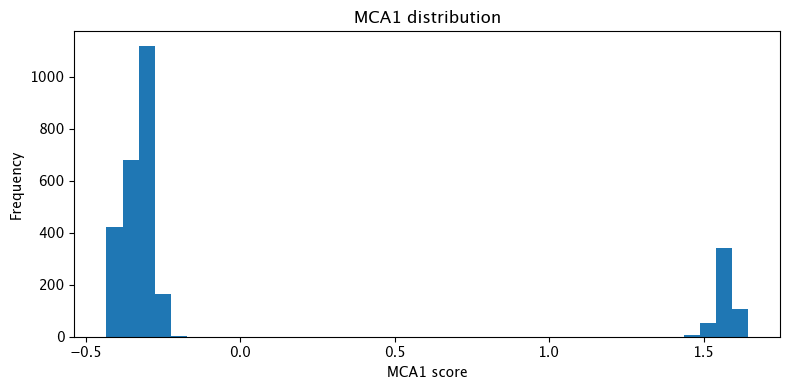

Figure saved to: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/mca1_histogram.png


In [ ]:
# Distribution plot for MCA1
plt.figure(figsize=(8, 4))
plt.hist(manzanas_completas['MCA1'].dropna(), bins=40)
plt.title('MCA1 distribution')
plt.xlabel('MCA1 score')
plt.ylabel('Frequency')
plt.tight_layout()
out_path = FIG_DIR / 'mca1_histogram.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', out_path)

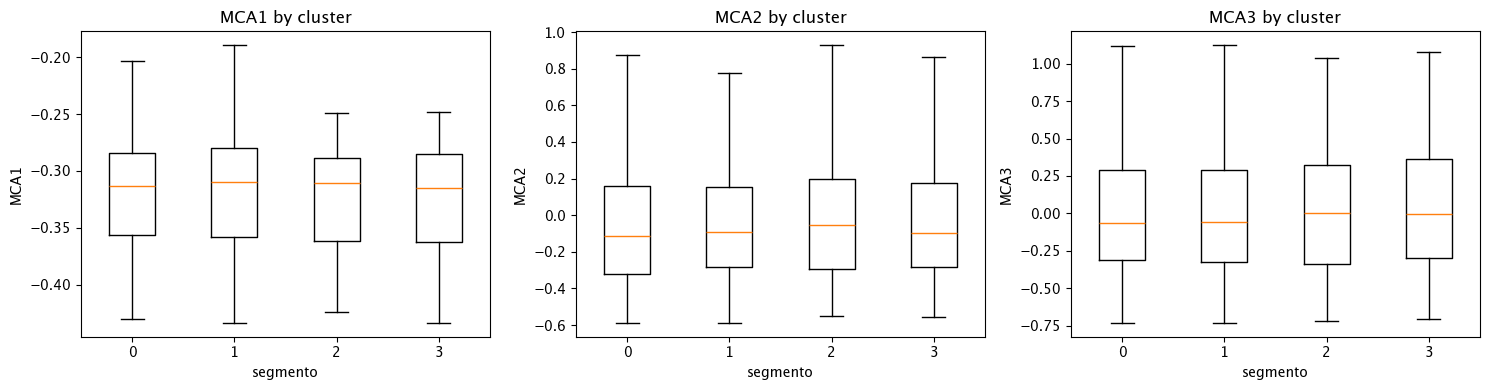

Figure saved to: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/mca_dims_by_cluster_boxplot.png


In [ ]:
# Cluster-wise boxplots for first available MCA axes (analogous structure to PCA section)
plot_dims = [c for c in ['MCA1', 'MCA2', 'MCA3'] if c in manzanas_completas.columns]
clusters_sorted = sorted(pd.Series(manzanas_completas['segmento']).dropna().unique())

if len(plot_dims) == 0:
    raise ValueError('No MCA dimensions found for plotting')

fig, axes = plt.subplots(1, len(plot_dims), figsize=(5 * len(plot_dims), 4), sharey=False)
if len(plot_dims) == 1:
    axes = [axes]

for ax, dim in zip(axes, plot_dims):
    data = [manzanas_completas.loc[manzanas_completas['segmento'] == k, dim].dropna() for k in clusters_sorted]
    ax.boxplot(data, labels=[str(k) for k in clusters_sorted], showfliers=False)
    ax.set_title(f'{dim} by cluster')
    ax.set_xlabel('segmento')
    ax.set_ylabel(dim)

plt.tight_layout()
out_path = FIG_DIR / 'mca_dims_by_cluster_boxplot.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', out_path)

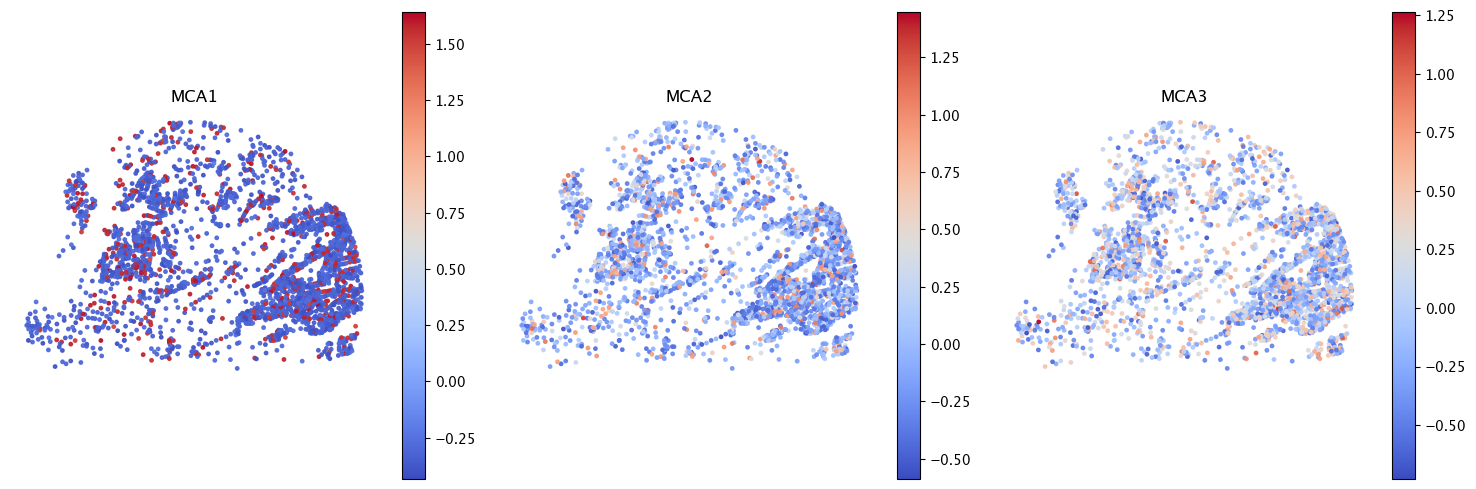

Figure saved to: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/mca123_spatial_maps.png


In [ ]:
# MCA1/MCA2/MCA3 spatial maps
g = manzanas_completas.copy()
if 'geometry' not in g.columns:
    g = gpd.GeoDataFrame(g, geometry=gpd.points_from_xy(g['lon'], g['lat']), crs='EPSG:4326')
else:
    g = gpd.GeoDataFrame(g, geometry='geometry', crs='EPSG:4326')

g = g.to_crs(epsg=3857)
cols = [c for c in ['MCA1', 'MCA2', 'MCA3'] if c in g.columns]
cmap = 'coolwarm'

if len(cols) == 0:
    raise ValueError('No MCA1/MCA2/MCA3 columns found for spatial plotting')

fig, axes = plt.subplots(1, len(cols), figsize=(5 * len(cols), 5))
if len(cols) == 1:
    axes = [axes]

geom_type = g.geometry.iloc[0].geom_type
for ax, c_name in zip(axes, cols):
    if geom_type in ('Polygon', 'MultiPolygon'):
        g.plot(ax=ax, column=c_name, cmap=cmap, legend=True, linewidth=0.2, edgecolor='white')
    else:
        g.plot(ax=ax, column=c_name, cmap=cmap, markersize=6, legend=True, alpha=0.9)
    ax.set_title(c_name, fontsize=12)
    ax.set_axis_off()

plt.tight_layout()
out_path = FIG_DIR / 'mca123_spatial_maps.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', out_path)


p-median optimization setup

In [ ]:
import math
from collections import defaultdict

import pulp

In [ ]:
# Directories and model hyperparameters
# Parameters are defined in the EXPERIMENT CONFIGURATION cell above.
# This cell only sets up the output directory and prints a summary.
# ── DO NOT re-define D_MAX, S_MIN, BETA etc here; they come from config ──
RESULTS_DIR = PROJECT_ROOT / 'experimentos'  / 'industrial'  / 'outputs' / 'tables' / 'resultados_clusters'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Confirm config values are in scope (fail loudly if config cell was skipped)
for _var in ['D_MAX', 'S_MIN', 'BETA', 'P_NEW_PER_CLUSTER', 'PENALTY_UNCOVERED', 'TIME_LIMIT_SEC']:
    assert _var in dir(), f"Config variable {_var!r} not found — run the EXPERIMENT CONFIGURATION cell first."

print('RESULTS_DIR =', RESULTS_DIR)
print({'D_MAX': D_MAX, 'S_MIN': S_MIN, 'BETA': BETA,
       'P_NEW_PER_CLUSTER': P_NEW_PER_CLUSTER, 'PENALTY_UNCOVERED': PENALTY_UNCOVERED})

RESULTS_DIR = /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/tables/resultados_clusters
{'D_MAX': 366.0, 'S_MIN': 240.0, 'BETA': 0.25, 'P_NEW_PER_CLUSTER': 7, 'PENALTY_UNCOVERED': 5000.0}


In [ ]:
# Build condensed table (compatible with previous pipeline naming)
if len(manzanas_completas) != len(gdf_nodos):
    raise ValueError('Length mismatch between manzanas_completas and gdf_nodos; cannot align graph_node reliably')

data_condensed = manzanas_completas[['lat', 'lon', 'segmento', 'POBTOT', 'oxxo_presente', 'MCA1', 'MCA1_weight', 'es_candidato']].copy().reset_index(drop=True)
data_condensed['segmento_gmm'] = data_condensed['segmento']  # compatibility alias
data_condensed['node_id'] = np.arange(len(data_condensed), dtype=int)
data_condensed['graph_node'] = gdf_nodos.reset_index(drop=True)['graph_node'].astype(int).values

condensed_path = PROCESSED_DIR / 'condensado.csv'
data_condensed.to_csv(condensed_path, index=False)
print('Saved:', condensed_path)
print('condensado shape:', data_condensed.shape)
data_condensed.head(3)

Saved: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/data/industrial/processed/condensado.csv
condensado shape: (2889, 11)


,lat,lon,segmento,POBTOT,oxxo_presente,MCA1,MCA1_weight,es_candidato,segmento_gmm,node_id,graph_node
0,19.401266,-99.282355,1,151,0,-0.391395,0.020273,True,1,0,8341151876
1,19.384047,-99.295140,1,59,0,1.569111,0.964091,True,1,1,6414853426
2,19.350110,-99.251535,0,367,0,-0.314293,0.057391,False,0,2,1393179349


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# PROPORTIONAL / DEMAND-WEIGHTED CLUSTER OPENING ALLOCATION
# Addresses Reviewer 2: "Assigning 7 openings per cluster regardless of size
# can generate inequities."  Three modes are supported:
#   fixed            — original behaviour (P_NEW_PER_CLUSTER per cluster)
#   proportional     — allocate P_NEW_TOTAL proportional to cluster block count
#   demand_weighted  — allocate P_NEW_TOTAL proportional to total weighted demand
# ══════════════════════════════════════════════════════════════════════════════

def compute_pnew_per_cluster(df_I, cluster_ids, mode, pnew_fixed, pnew_total):
    if mode == "fixed":
        return {int(c): int(pnew_fixed) for c in cluster_ids}

    if mode == "proportional":
        weights = df_I.groupby('cluster_i').size().reindex(cluster_ids, fill_value=0).astype(float)
    elif mode == "demand_weighted":
        weights = df_I.groupby('cluster_i')['w'].sum().reindex(cluster_ids, fill_value=0.0)
    else:
        raise ValueError(f"Unknown P_NEW_MODE: {mode!r}")

    total_w = float(weights.sum())
    if total_w == 0:
        raise ValueError("Total weight is zero; cannot allocate openings.")

    raw = (weights / total_w * pnew_total).to_dict()
    alloc = {c: max(1, int(round(v))) for c, v in raw.items()}

    diff = pnew_total - sum(alloc.values())
    sorted_c = sorted(alloc, key=lambda c: raw[c] - int(round(raw[c])), reverse=(diff > 0))
    for c in sorted_c[:abs(diff)]:
        alloc[c] += 1 if diff > 0 else -1
        alloc[c] = max(1, alloc[c])

    return {int(c): int(v) for c, v in alloc.items()}



In [ ]:

def build_pmedian_inputs_graph(df_plot, G_graph, D_MAX=366.0, S_MIN=240.0, beta=0.25, cluster_col='segmento'):
    # Build p-median sets using shortest-path graph distances.

    req = ['node_id', 'graph_node', 'lat', 'lon', cluster_col, 'POBTOT', 'MCA1', 'oxxo_presente', 'es_candidato']
    miss = [c for c in req if c not in df_plot.columns]
    if miss:
        raise ValueError(f'Missing required columns for p-median build: {miss}')

    df = df_plot.copy().reset_index(drop=True)

    df['node_id'] = pd.to_numeric(df['node_id'], errors='coerce').astype('Int64')
    df['graph_node'] = pd.to_numeric(df['graph_node'], errors='coerce').astype('Int64')
    df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
    df['lon'] = pd.to_numeric(df['lon'], errors='coerce')
    df['POBTOT'] = pd.to_numeric(df['POBTOT'], errors='coerce').fillna(0.0)
    df['MCA1'] = pd.to_numeric(df['MCA1'], errors='coerce').fillna(0.0)
    df['oxxo_presente'] = pd.to_numeric(df['oxxo_presente'], errors='coerce').fillna(0).astype(int)
    df['es_candidato'] = df['es_candidato'].astype(bool)
    df[cluster_col] = pd.to_numeric(df[cluster_col], errors='coerce').fillna(-1).astype(int)

    df = df.dropna(subset=['node_id', 'graph_node', 'lat', 'lon']).copy()
    df['node_id'] = df['node_id'].astype(int)
    df['graph_node'] = df['graph_node'].astype(int)

    # I: demand
    df_I = df[df['POBTOT'] > 0][['node_id', 'graph_node', 'POBTOT', 'MCA1', 'lat', 'lon', cluster_col]].copy()
    df_I.rename(columns={cluster_col: 'cluster_i'}, inplace=True)

    mca1 = df_I['MCA1'].astype(float)
    std = float(mca1.std(ddof=0)) if len(mca1) > 1 else 0.0
    denom = std if np.isfinite(std) and std > 0 else 1.0
    mca1_z = (mca1 - float(mca1.mean())) / denom
    w = df_I['POBTOT'] * (1.0 + beta * mca1_z.fillna(0.0))
    df_I['w'] = w.clip(lower=0.0)
    df_I['i'] = np.arange(len(df_I), dtype=int)

    # E: existing
    df_E = df[df['oxxo_presente'] > 0][['node_id', 'graph_node', 'lat', 'lon', cluster_col]].copy()
    df_E.rename(columns={cluster_col: 'cluster_p'}, inplace=True)
    df_E['p'] = np.arange(len(df_E), dtype=int)
    df_E['es_existente'] = True

    # J raw candidates
    df_J_raw = df[(df['oxxo_presente'] == 0) & (df['es_candidato'])][['node_id', 'graph_node', 'lat', 'lon', cluster_col]].copy()
    df_J_raw.rename(columns={cluster_col: 'cluster_p'}, inplace=True)

    # Filter J by S_MIN to existing (graph shortest path)
    if len(df_E) > 0 and len(df_J_raw) > 0:
        dist_to_E = nx.multi_source_dijkstra_path_length(
            G_graph,
            sources=set(df_E['graph_node'].astype(int).unique().tolist()),
            weight='length'
        )
        dvals = df_J_raw['graph_node'].map(lambda n: float(dist_to_E.get(int(n), np.inf)))
        df_J = df_J_raw[dvals >= S_MIN].copy()
    else:
        df_J = df_J_raw.copy()

    df_J = df_J.reset_index(drop=True)
    df_J['j'] = np.arange(len(df_J), dtype=int)
    df_J['p'] = np.arange(len(df_E), len(df_E) + len(df_J), dtype=int)
    df_J['es_existente'] = False

    # P = E union J
    colsP = ['p', 'node_id', 'graph_node', 'lat', 'lon', 'cluster_p', 'es_existente']
    df_P = pd.concat([df_E[colsP], df_J[colsP]], ignore_index=True)

    # A arcs (i,p) within D_MAX graph distance
    p_by_node = defaultdict(list)
    for r in df_P.itertuples(index=False):
        p_by_node[int(r.graph_node)].append(int(r.p))
    p_nodes = set(p_by_node.keys())

    i_by_node = defaultdict(list)
    for r in df_I.itertuples(index=False):
        i_by_node[int(r.graph_node)].append(int(r.i))

    arc_rows = []
    total_sources = len(i_by_node)
    for n_src, (src_node, i_list) in enumerate(i_by_node.items(), start=1):
        lengths = nx.single_source_dijkstra_path_length(
            G_graph,
            source=int(src_node),
            cutoff=float(D_MAX),
            weight='length'
        )

        p_dist = []
        for node, dist in lengths.items():
            if node in p_nodes:
                for p in p_by_node[node]:
                    p_dist.append((int(p), float(dist)))

        if p_dist:
            for i_id in i_list:
                for p_id, d in p_dist:
                    arc_rows.append((int(i_id), int(p_id), float(d)))

        if (n_src % 300 == 0) or (n_src == total_sources):
            print(f'Arcs progress: {n_src}/{total_sources} source nodes')

    df_A = pd.DataFrame(arc_rows, columns=['i', 'p', 'dist_m'])
    if len(df_A) > 0:
        df_A = (
            df_A.groupby(['i', 'p'], as_index=False)['dist_m']
            .min()
            .sort_values(['i', 'p'])
            .reset_index(drop=True)
        )

    # Candidate conflicts (j,k) if graph distance < S_MIN
    conflict_rows = []
    if len(df_J) > 1:
        gdfJ = gpd.GeoDataFrame(
            df_J[['j', 'graph_node', 'lat', 'lon']].copy(),
            geometry=gpd.points_from_xy(df_J['lon'], df_J['lat']),
            crs='EPSG:4326'
        ).to_crs(epsg=PROJ_EPSG)

        coords = np.column_stack([gdfJ.geometry.x.values, gdfJ.geometry.y.values])
        nbrs = NearestNeighbors(radius=float(S_MIN), metric='euclidean').fit(coords)
        neigh_idx = nbrs.radius_neighbors(coords, return_distance=False)

        sp_cache = {}

        def sp_cached(a, b):
            key = (a, b) if a <= b else (b, a)
            if key in sp_cache:
                return sp_cache[key]
            if a == b:
                sp_cache[key] = 0.0
                return 0.0
            try:
                d = float(nx.shortest_path_length(G_graph, source=int(a), target=int(b), weight='length'))
            except nx.NetworkXNoPath:
                d = np.inf
            sp_cache[key] = d
            return d

        graph_nodes_j = df_J['graph_node'].astype(int).to_numpy()
        j_ids = df_J['j'].astype(int).to_numpy()

        for idx_j, neigh in enumerate(neigh_idx):
            for idx_k in neigh:
                if idx_k <= idx_j:
                    continue
                d_jk = sp_cached(int(graph_nodes_j[idx_j]), int(graph_nodes_j[idx_k]))
                if d_jk < S_MIN:
                    conflict_rows.append((int(j_ids[idx_j]), int(j_ids[idx_k]), float(d_jk)))

    df_conflictos = pd.DataFrame(conflict_rows, columns=['j', 'k', 'dist_m'])
    if len(df_conflictos) > 0:
        df_conflictos = df_conflictos.drop_duplicates(['j', 'k']).reset_index(drop=True)

    params = {
        'D_MAX': float(D_MAX),
        'S_MIN': float(S_MIN),
        'beta': float(beta),
        'n_I': int(len(df_I)),
        'n_E': int(len(df_E)),
        'n_J': int(len(df_J)),
        'n_P': int(len(df_P)),
        'n_A': int(len(df_A)),
        'n_conflictos': int(len(df_conflictos))
    }

    return (
        df_I.reset_index(drop=True),
        df_E.reset_index(drop=True),
        df_J.reset_index(drop=True),
        df_P.reset_index(drop=True),
        df_A,
        df_conflictos,
        params,
    )


In [ ]:
df_I, df_E, df_J, df_P, df_A, df_conflictos, params = build_pmedian_inputs_graph(
    data_condensed,
    G_proj,
    D_MAX=D_MAX,
    S_MIN=S_MIN,
    beta=BETA,
    cluster_col='segmento'
)

print('Shapes:')
print('df_I', df_I.shape, 'df_E', df_E.shape, 'df_J', df_J.shape, 'df_P', df_P.shape, 'df_A', df_A.shape, 'df_conflictos', df_conflictos.shape)
print('Params:', params)

Arcs progress: 300/2093 source nodes
Arcs progress: 600/2093 source nodes
Arcs progress: 900/2093 source nodes
Arcs progress: 1200/2093 source nodes
Arcs progress: 1500/2093 source nodes
Arcs progress: 1800/2093 source nodes
Arcs progress: 2093/2093 source nodes
Shapes:
df_I (2693, 9) df_E (6, 7) df_J (1521, 8) df_P (1527, 7) df_A (18643, 3) df_conflictos (4539, 3)
Params: {'D_MAX': 366.0, 'S_MIN': 240.0, 'beta': 0.25, 'n_I': 2693, 'n_E': 6, 'n_J': 1521, 'n_P': 1527, 'n_A': 18643, 'n_conflictos': 4539}


In [ ]:
pnew_per_cluster_map = compute_pnew_per_cluster(
    df_I=df_I,
    cluster_ids=sorted(df_I['cluster_i'].dropna().astype(int).unique().tolist()),
    mode=P_NEW_MODE,
    pnew_fixed=P_NEW_PER_CLUSTER,
    pnew_total=P_NEW_TOTAL,
)

print(f"P_NEW_MODE = {P_NEW_MODE!r}")
print("Openings per cluster:")
for c, n in sorted(pnew_per_cluster_map.items()):
    n_blocks = int((df_I['cluster_i'] == c).sum())
    print(f"  Cluster {c}: {n:2d} openings  ({n_blocks} demand blocks)")
print(f"  Total new openings: {sum(pnew_per_cluster_map.values())}")

P_NEW_MODE = 'fixed'
Openings per cluster:
  Cluster 0:  7 openings  (1117 demand blocks)
  Cluster 1:  7 openings  (1110 demand blocks)
  Cluster 2:  7 openings  (245 demand blocks)
  Cluster 3:  7 openings  (221 demand blocks)
  Total new openings: 28


In [ ]:

def pack_pmedian_bundle(df_I, df_P, df_A, df_conflictos=None, params=None):
    params = dict(params or {})
    cols = [
        'kind', 'i', 'p', 'j', 'k', 'w', 'dist_m', 'es_existente', 'name', 'value',
        'uid_i', 'uid_p', 'cluster_i', 'cluster_p'
    ]
    rows = []

    for r in df_I.itertuples(index=False):
        rows.append(dict(kind='I', i=int(r.i), w=float(r.w), uid_i=int(r.node_id), cluster_i=int(r.cluster_i)))

    for r in df_P.itertuples(index=False):
        rows.append(dict(kind='P', p=int(r.p), es_existente=bool(r.es_existente), uid_p=int(r.node_id), cluster_p=int(r.cluster_p)))

    for r in df_A.itertuples(index=False):
        rows.append(dict(kind='A', i=int(r.i), p=int(r.p), dist_m=float(r.dist_m)))

    if df_conflictos is not None and len(df_conflictos) > 0:
        for r in df_conflictos.itertuples(index=False):
            j, k = int(r.j), int(r.k)
            if j != k:
                j, k = sorted((j, k))
                rows.append(dict(kind='C', j=j, k=k, dist_m=float(r.dist_m)))

    for k, v in params.items():
        rows.append(dict(kind='PARAM', name=str(k), value=v))

    out = pd.DataFrame(rows)
    for c in cols:
        if c not in out.columns:
            out[c] = pd.NA
    return out[cols]


df_bundle = pack_pmedian_bundle(df_I, df_P, df_A, df_conflictos, params)

bundle_csv = PROCESSED_DIR / 'pmedian_bundle.csv'
bundle_parquet = PROCESSED_DIR / 'pmedian_bundle.parquet'
bundle_wc_csv = PROCESSED_DIR / 'pmedian_bundle_with_clusters.csv'
bundle_wc_parquet = PROCESSED_DIR / 'pmedian_bundle_with_clusters.parquet'

df_bundle.to_csv(bundle_csv, index=False)
df_bundle.to_parquet(bundle_parquet, index=False)
df_bundle.to_csv(bundle_wc_csv, index=False)
df_bundle.to_parquet(bundle_wc_parquet, index=False)

print('Saved:', bundle_csv)
print('Saved:', bundle_parquet)
print('Saved:', bundle_wc_csv)
print('Saved:', bundle_wc_parquet)
print('Bundle shape:', df_bundle.shape)


Saved: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/data/industrial/processed/pmedian_bundle.csv
Saved: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/data/industrial/processed/pmedian_bundle.parquet
Saved: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/data/industrial/processed/pmedian_bundle_with_clusters.csv
Saved: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/data/industrial/processed/pmedian_bundle_with_clusters.parquet
Bundle shape: (27411, 14)


 Clustered optimization model

# Modelo de localizacion propuesto (p-mediana con red vial y no-cobertura)

## Conjuntos (por cluster resuelto)

- $I_c$: nodos de demanda del cluster $c$ (manzanas con $\text{POBTOT}>0$).
- $E$: tiendas existentes (siempre activas).
- $J_c$: candidatos del cluster $c$, previamente filtrados.
- $P_c = E \cup J_c$: ubicaciones que pueden atender demanda al resolver el cluster $c$.
- $\mathcal{A}_c = \{(i,p) : i\in I_c,\ p\in P_c,\ d_{ip}\le D_{\max}\}$: arcos factibles de asignacion.
- $\mathcal{C}_c = \{(j,k)\subseteq J_c : d_{jk}<S_{\min}\}$: pares candidatos en conflicto por separacion minima.

## Parametros

| Simbolo | Descripcion |
|---------|-------------|
| $d_{ip}$ | Distancia de camino mas corto (red peatonal) entre demanda $i$ y ubicacion $p$, en metros |
| $D_{\max}$ | Distancia maxima de cobertura |
| $S_{\min}$ | Separacion minima entre nuevas aperturas |
| $P_c^{\text{new}}$ | Numero de nuevas tiendas a abrir en el cluster $c$ |
| $\lambda$ | Penalizacion por demanda no cubierta |
| $\beta$ | Factor de escala del indice socio-urbano en la demanda ponderada |

Demanda ponderada en el nodo $i$:

$$w_i = \text{POBTOT}_i \left[1 + \beta\, z(\text{MCA1\_weight}_i)\right]_+$$

donde $z(\cdot)$ es la puntuacion normalizada $[0,1]$ del indice MCA1.

## Variables de decision

| Variable | Dominio | Descripcion |
|----------|---------|-------------|
| $y_p$ | $\{0,1\}$, $p\in J_c$ | 1 si se abre la candidata $p$ |
| $x_{ip}$ | $\{0,1\}$, $(i,p)\in\mathcal{A}_c$ | 1 si la demanda $i$ se asigna a $p$ |
| $u_i$ | $\{0,1\}$, $i\in I_c$ | 1 si $i$ queda no cubierta |

## Funcion objetivo

Minimizar distancia ponderada de acceso mas penalizacion por no cobertura:

$$\min \sum_{(i,p)\in\mathcal{A}_c} w_i\, d_{ip}\, x_{ip} \;+\; \lambda \sum_{i\in I_c} w_i\, u_i$$

## Restricciones

**1. Asignacion o no-cobertura (exclusiva)** — cada nodo de demanda se asigna exactamente a una ubicacion o queda descubierto:

$$\sum_{p:\,(i,p)\in\mathcal{A}_c} x_{ip} + u_i = 1 \qquad \forall\, i\in I_c$$

**2. Activacion de candidatas** — solo se puede asignar demanda a una candidata si esta abierta:

$$x_{ij} \le y_j \qquad \forall\, (i,j)\in\mathcal{A}_c,\ j\in J_c$$

Para existentes $e\in E$ no se requiere variable de apertura.

**3. Numero exacto de nuevas aperturas por cluster:**

$$\sum_{j\in J_c} y_j = P_c^{\text{new}}$$

**4. Cobertura maxima** — arcos con $d_{ip}>D_{\max}$ se excluyen al construir $\mathcal{A}_c$:

$$x_{ip} = 0 \qquad \text{si } d_{ip} > D_{\max}$$

**5. Separacion minima entre nuevas aperturas:**

$$y_j + y_k \le 1 \qquad \forall\, (j,k)\in\mathcal{C}_c$$

**6. Dominio de variables:**

$$x_{ip},\ y_j,\ u_i \in \{0,1\}$$

---

## Notas de implementacion

1. Se usa la red peatonal (OSMnx) para calcular $d_{ip}$ mediante Dijkstra de multiples fuentes.
2. Los candidatos $J_c$ se filtran previamente: $d(j,e)\ge S_{\min}$ para todo existente $e\in E$.
3. Los arcos $\mathcal{A}_c$ se generan con $d_{ip}\le D_{\max}$.
4. Los pares de conflicto $\mathcal{C}_c$ se generan con $d_{jk}<S_{\min}$.
5. Se resuelve un MILP por cluster (PuLP/CBC) y se exportan aperturas, asignaciones y metricas.

In [ ]:

def solve_cluster_model(
    cluster_id,
    df_I,
    df_J,
    df_P,
    df_A,
    df_conflictos,
    j_to_p_map,
    p_new_per_cluster=7,
    penalty_uncovered=5000.0,
    time_limit_sec=300,
    solver_msg=False,
):
    I_c = df_I[df_I['cluster_i'] == cluster_id].copy()
    if len(I_c) == 0:
        empty_assign = pd.DataFrame(columns=['i','p','dist_m','uncovered','cluster_solved','lat_i','lon_i','cluster_i','w_i','lat_p','lon_p','cluster_p'])
        empty_open = pd.DataFrame(columns=['id','lat','lon','cluster','opened','cluster_solved'])
        metrics = {
            'cluster': int(cluster_id),
            'opened': 0,
            'n_demands': 0,
            'covered': 0,
            'pct_covered': np.nan,
            'mean_dist_m': np.nan,
            'w_mean_dist_m': np.nan,
            'objective_value': np.nan,
        }
        return empty_assign, empty_open, metrics, 'NO_DEMAND'

    existing_all = df_P[df_P['es_existente']].copy()
    cand_local = df_P[(~df_P['es_existente']) & (df_P['cluster_p'] == cluster_id)].copy()

    P_local = pd.concat([existing_all, cand_local], ignore_index=True)
    P_local_set = set(P_local['p'].astype(int).tolist())

    A_c = df_A[df_A['i'].isin(I_c['i']) & df_A['p'].isin(P_local_set)].copy()

    model = pulp.LpProblem(f'cluster_{cluster_id}_pmedian', pulp.LpMinimize)

    x = {}
    for r in A_c.itertuples(index=False):
        key = (int(r.i), int(r.p))
        x[key] = pulp.LpVariable(f'x_{key[0]}_{key[1]}', lowBound=0, upBound=1, cat='Binary')

    u = {int(i): pulp.LpVariable(f'u_{int(i)}', lowBound=0, upBound=1, cat='Binary') for i in I_c['i'].astype(int).tolist()}
    y = {int(p): pulp.LpVariable(f'y_{int(p)}', lowBound=0, upBound=1, cat='Binary') for p in cand_local['p'].astype(int).tolist()}

    w_map = dict(zip(I_c['i'].astype(int), I_c['w'].astype(float)))

    arcs_by_i = defaultdict(list)
    dist_map = {}
    for r in A_c.itertuples(index=False):
        i_id, p_id, d = int(r.i), int(r.p), float(r.dist_m)
        arcs_by_i[i_id].append(p_id)
        dist_map[(i_id, p_id)] = d

    assign_cost = [w_map[i] * dist_map[(i, p)] * x[(i, p)] for (i, p) in x.keys()]
    uncovered_cost = [penalty_uncovered * w_map[i] * u[i] for i in u.keys()]
    model += pulp.lpSum(assign_cost + uncovered_cost)

    for i_id in I_c['i'].astype(int).tolist():
        p_list = arcs_by_i.get(i_id, [])
        if len(p_list) == 0:
            model += (u[i_id] == 1), f'uncovered_forced_{i_id}'
        else:
            model += (pulp.lpSum(x[(i_id, p)] for p in p_list) + u[i_id] == 1), f'assign_or_uncovered_{i_id}'

    for (i_id, p_id), var in x.items():
        if p_id in y:
            model += (var <= y[p_id]), f'link_{i_id}_{p_id}'

    if len(y) > 0:
        p_target = min(int(p_new_per_cluster), len(y))
        model += (pulp.lpSum(y.values()) == p_target), f'open_exactly_{cluster_id}'

    if len(y) > 0 and len(df_conflictos) > 0:
        for r in df_conflictos.itertuples(index=False):
            p_j = j_to_p_map.get(int(r.j))
            p_k = j_to_p_map.get(int(r.k))
            if (p_j in y) and (p_k in y):
                model += (y[p_j] + y[p_k] <= 1), f'conf_{cluster_id}_{int(r.j)}_{int(r.k)}'

    solver = pulp.PULP_CBC_CMD(msg=solver_msg, timeLimit=int(time_limit_sec))
    model.solve(solver)
    status = pulp.LpStatus.get(model.status, str(model.status))

    p_lookup = df_P.set_index('p')[['node_id','lat','lon','cluster_p','es_existente']].to_dict(orient='index')
    i_lookup = I_c.set_index('i')[['lat','lon','cluster_i','w']].to_dict(orient='index')

    assign_rows = []
    for i_id, i_info in i_lookup.items():
        assigned_p = None
        assigned_d = np.nan
        for p_id in arcs_by_i.get(int(i_id), []):
            var = x.get((int(i_id), int(p_id)))
            if var is not None and pulp.value(var) is not None and pulp.value(var) > 0.5:
                assigned_p = int(p_id)
                assigned_d = float(dist_map[(int(i_id), int(p_id))])
                break

        is_uncovered = 1
        if assigned_p is not None:
            is_uncovered = 0

        row = {
            'i': int(i_id),
            'p': float(assigned_p) if assigned_p is not None else np.nan,
            'dist_m': float(assigned_d) if assigned_p is not None else np.nan,
            'uncovered': int(is_uncovered),
            'cluster_solved': int(cluster_id),
            'lat_i': float(i_info['lat']),
            'lon_i': float(i_info['lon']),
            'cluster_i': int(i_info['cluster_i']),
            'w_i': float(i_info['w']),
            'lat_p': np.nan,
            'lon_p': np.nan,
            'cluster_p': np.nan,
        }

        if assigned_p is not None:
            p_info = p_lookup.get(int(assigned_p), None)
            if p_info is not None:
                row['lat_p'] = float(p_info['lat'])
                row['lon_p'] = float(p_info['lon'])
                row['cluster_p'] = float(p_info['cluster_p'])

        assign_rows.append(row)

    assign_df = pd.DataFrame(assign_rows)

    open_rows = []
    for p_id, var in y.items():
        val = pulp.value(var)
        if val is not None and val > 0.5:
            info = p_lookup[int(p_id)]
            open_rows.append({
                'id': int(info['node_id']),
                'lat': float(info['lat']),
                'lon': float(info['lon']),
                'cluster': int(info['cluster_p']),
                'opened': 1,
                'cluster_solved': int(cluster_id),
            })

    open_df = pd.DataFrame(open_rows, columns=['id','lat','lon','cluster','opened','cluster_solved'])

    covered_df = assign_df[assign_df['uncovered'] == 0].copy()
    covered = int(len(covered_df))
    n_demands = int(len(assign_df))
    pct_covered = (covered / n_demands) if n_demands > 0 else np.nan

    if covered > 0:
        mean_dist = float(covered_df['dist_m'].mean())
        wsum = float(covered_df['w_i'].sum())
        w_mean_dist = float((covered_df['dist_m'] * covered_df['w_i']).sum() / wsum) if wsum > 0 else np.nan
    else:
        mean_dist = np.nan
        w_mean_dist = np.nan

    metrics = {
        'cluster': int(cluster_id),
        'opened': int(len(open_df)),
        'n_demands': int(n_demands),
        'covered': int(covered),
        'pct_covered': float(pct_covered) if pd.notna(pct_covered) else np.nan,
        'mean_dist_m': float(mean_dist) if pd.notna(mean_dist) else np.nan,
        'w_mean_dist_m': float(w_mean_dist) if pd.notna(w_mean_dist) else np.nan,
        'objective_value': float(pulp.value(model.objective)) if pulp.value(model.objective) is not None else np.nan,
    }

    return assign_df, open_df, metrics, status


In [ ]:

# Run clustered optimization and export per-cluster/global tables
clusters_to_solve = sorted(df_I['cluster_i'].dropna().astype(int).unique().tolist())
print('Clusters to solve:', clusters_to_solve)

j_to_p_map = dict(df_J[['j', 'p']].astype(int).itertuples(index=False, name=None)) if len(df_J) > 0 else {}

all_assign = []
all_open = []
metrics_rows = []
status_rows = []

for c in clusters_to_solve:
    print(f'\nSolving cluster {c} ...')
    assign_c, open_c, metrics_c, status_c = solve_cluster_model(
        cluster_id=int(c),
        df_I=df_I,
        df_J=df_J,
        df_P=df_P,
        df_A=df_A,
        df_conflictos=df_conflictos,
        j_to_p_map=j_to_p_map,
        p_new_per_cluster=pnew_per_cluster_map.get(int(c), P_NEW_PER_CLUSTER),
        penalty_uncovered=PENALTY_UNCOVERED,
        time_limit_sec=TIME_LIMIT_SEC,
        solver_msg=False,
    )

    status_rows.append({'cluster': int(c), 'solver_status': status_c})

    assign_path = RESULTS_DIR / f'asignaciones_cluster{int(c)}.csv'
    open_path = RESULTS_DIR / f'aperturas_cluster{int(c)}.csv'

    assign_c.to_csv(assign_path, index=False)
    open_c.to_csv(open_path, index=False)

    print(f"  status={status_c} | opened={metrics_c['opened']} | covered={metrics_c['covered']}/{metrics_c['n_demands']}")

    all_assign.append(assign_c)
    all_open.append(open_c)
    metrics_rows.append(metrics_c)

asignaciones_global = pd.concat(all_assign, ignore_index=True) if all_assign else pd.DataFrame(columns=['i','p','dist_m','uncovered','cluster_solved','lat_i','lon_i','cluster_i','w_i','lat_p','lon_p','cluster_p'])
aperturas_global = pd.concat(all_open, ignore_index=True) if all_open else pd.DataFrame(columns=['id','lat','lon','cluster','opened','cluster_solved'])
metrics_por_cluster = pd.DataFrame(metrics_rows).sort_values('cluster').reset_index(drop=True)
status_por_cluster = pd.DataFrame(status_rows).sort_values('cluster').reset_index(drop=True)

covered_global = asignaciones_global[asignaciones_global['uncovered'] == 0].copy()
n_demands_total = int(len(asignaciones_global))
covered_total = int(len(covered_global))

if covered_total > 0:
    mean_dist_total = float(covered_global['dist_m'].mean())
    wsum_total = float(covered_global['w_i'].sum())
    w_mean_dist_total = float((covered_global['dist_m'] * covered_global['w_i']).sum() / wsum_total) if wsum_total > 0 else np.nan
else:
    mean_dist_total = np.nan
    w_mean_dist_total = np.nan

metrics_global = pd.DataFrame([
    {
        'opened_total': int(len(aperturas_global)),
        'n_demands_total': int(n_demands_total),
        'covered_total': int(covered_total),
        'pct_covered_total': float(covered_total / n_demands_total) if n_demands_total > 0 else np.nan,
        'mean_dist_m_total': mean_dist_total,
        'w_mean_dist_m_total': w_mean_dist_total,
    }
])

asignaciones_global.to_csv(RESULTS_DIR / 'asignaciones_global.csv', index=False)
aperturas_global.to_csv(RESULTS_DIR / 'aperturas_global.csv', index=False)
metrics_por_cluster.to_csv(RESULTS_DIR / 'metrics_por_cluster.csv', index=False)
metrics_global.to_csv(RESULTS_DIR / 'metrics_global.csv', index=False)
status_por_cluster.to_csv(RESULTS_DIR / 'solver_status_por_cluster.csv', index=False)

print('\nSaved global results in', RESULTS_DIR)
print('metrics_global:')
print(metrics_global)
print('solver statuses:')
print(status_por_cluster)


Clusters to solve: [0, 1, 2, 3]

Solving cluster 0 ...
  status=Optimal | opened=7 | covered=188/1117

Solving cluster 1 ...
  status=Optimal | opened=7 | covered=230/1110

Solving cluster 2 ...
  status=Optimal | opened=7 | covered=59/245

Solving cluster 3 ...
  status=Optimal | opened=7 | covered=84/221

Saved global results in /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/tables/resultados_clusters
metrics_global:
   opened_total  n_demands_total  covered_total  pct_covered_total  \
0            28             2693            561           0.208318   

   mean_dist_m_total  w_mean_dist_m_total  
0         212.951751           198.518578  
solver statuses:
   cluster solver_status
0        0       Optimal
1        1       Optimal
2        2       Optimal
3        3       Optimal


visualizations

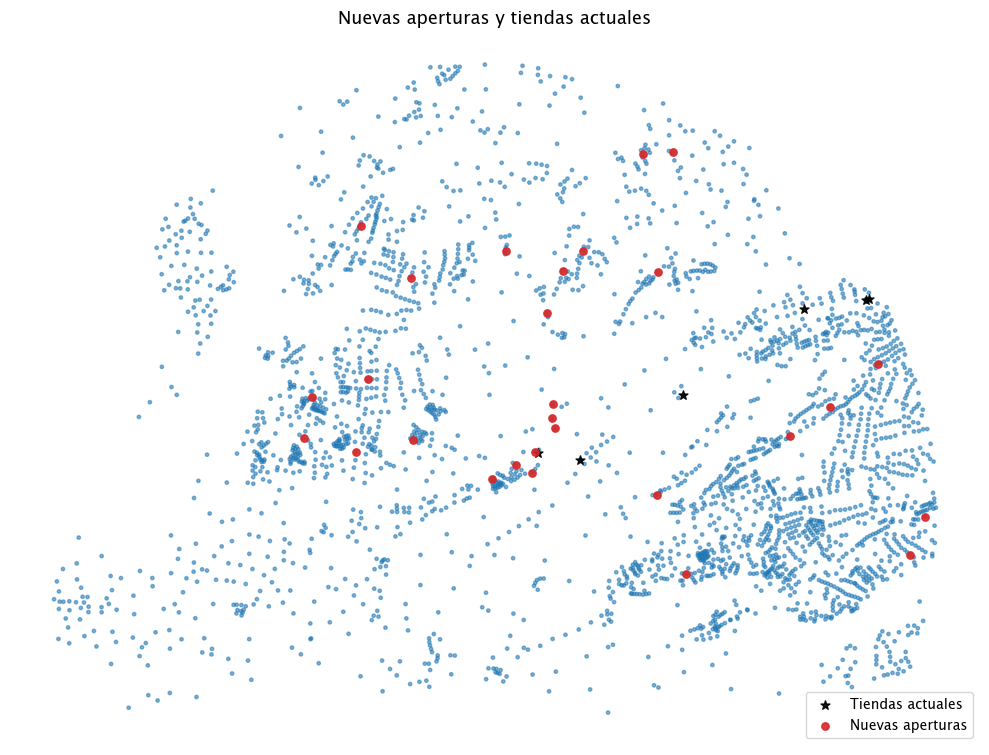

Figura guardada en: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/mapa_aperturas_global.png


In [ ]:

# Plot: nuevas aperturas + tiendas actuales
CSV_BASE = PROCESSED_DIR / 'condensado.csv'
CSV_OPEN = RESULTS_DIR / 'aperturas_global.csv'
OUT_PNG = FIG_DIR / 'mapa_aperturas_global.png'

df_base = pd.read_csv(CSV_BASE)
opens = pd.read_csv(CSV_OPEN)

gdf_base_pts = gpd.GeoDataFrame(
    df_base.copy(),
    geometry=gpd.points_from_xy(df_base['lon'], df_base['lat']),
    crs='EPSG:4326',
)

gdf_ox = gdf_base_pts.loc[gdf_base_pts['oxxo_presente'] == 1, ['oxxo_presente', 'geometry']].copy()

if len(opens) > 0:
    gdf_open = gpd.GeoDataFrame(
        opens.copy(),
        geometry=gpd.points_from_xy(opens['lon'], opens['lat']),
        crs='EPSG:4326',
    )
else:
    gdf_open = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

fig, ax = plt.subplots(figsize=(10, 10))

gdf_base_pts.plot(
    ax=ax,
    column='oxxo_presente' if 'oxxo_presente' in gdf_base_pts.columns else None,
    categorical='oxxo_presente' in gdf_base_pts.columns,
    legend='oxxo_presente' in gdf_base_pts.columns,
    markersize=6,
    alpha=0.55,
)

if len(gdf_ox) > 0:
    gdf_ox.plot(ax=ax, color='k', marker='*', markersize=45, alpha=0.9, label='Tiendas actuales')

if len(gdf_open) > 0:
    gdf_open.plot(ax=ax, color='tab:red', marker='o', markersize=28, alpha=0.9, label='Nuevas aperturas')

ax.set_title('Nuevas aperturas y tiendas actuales', fontsize=13)
ax.set_axis_off()
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(OUT_PNG, dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en:', OUT_PNG)


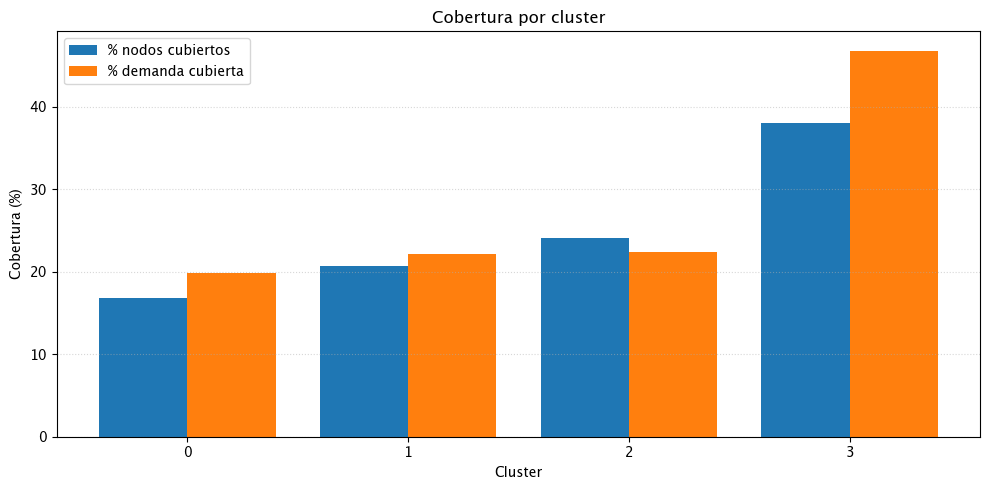

Figura guardada en: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/benchmark_cobertura_por_cluster.png


In [ ]:

# Benchmark: cobertura por cluster (no ponderado y ponderado por demanda)
METRICS = RESULTS_DIR / 'metrics_por_cluster.csv'
ASIG = RESULTS_DIR / 'asignaciones_global.csv'

m = pd.read_csv(METRICS).sort_values('cluster')
a = pd.read_csv(ASIG)

g = (
    a.groupby('cluster_i')
    .apply(lambda g: g.loc[g['uncovered'] == 0, 'w_i'].sum() / max(g['w_i'].sum(), 1e-9))
    .rename('pct_cov_weighted')
    .reset_index()
)

df_plot_cov = (
    m[['cluster', 'pct_covered']]
    .merge(g.rename(columns={'cluster_i': 'cluster'}), on='cluster', how='left')
)

x = df_plot_cov['cluster'].astype(int)
w = 0.4
fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(x - w / 2, 100 * df_plot_cov['pct_covered'], width=w, label='% nodos cubiertos')
ax.bar(x + w / 2, 100 * df_plot_cov['pct_cov_weighted'], width=w, label='% demanda cubierta')

ax.set_xticks(x)
ax.set_xlabel('Cluster')
ax.set_ylabel('Cobertura (%)')
ax.set_title('Cobertura por cluster')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
out = FIG_DIR / 'benchmark_cobertura_por_cluster.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada en:', out)


## Sensitivity Analysis & Parameter Justification

Addresses **Reviewer 2** ("Key parameters set without empirical justification") and **Reviewer 3** ("No sensitivity analysis for key parameters", "K parameter in k-NN is arbitrary", "threshold for underserved blocks is not justified").

Three sweeps are performed on the student-area data:
1. **Underserved-block threshold** — multiplier on `avg_nn_m`
2. **KNN affinity-graph K** — effect on clustering quality
3. **Beta (β)** — MCA demand-weight blending coefficient

A fourth sweep (**grid search** over D_MAX × S_MIN × p_new × beta) produces the Pareto frontier that justifies the chosen optimisation parameters.

> ⚠️ These sweeps use cached graph/cluster/MCA outputs and re-run only the lightweight parts of the pipeline.  The full grid search over optimisation parameters reuses pre-built p-median inputs for speed.


 multiplier  threshold_m  n_candidates  pct_candidates
       0.50       657.33          2157           74.66
       0.75       985.99          1808           62.58
       1.00      1314.66          1521           52.65
       1.25      1643.32          1339           46.35
       1.50      1971.99          1164           40.29


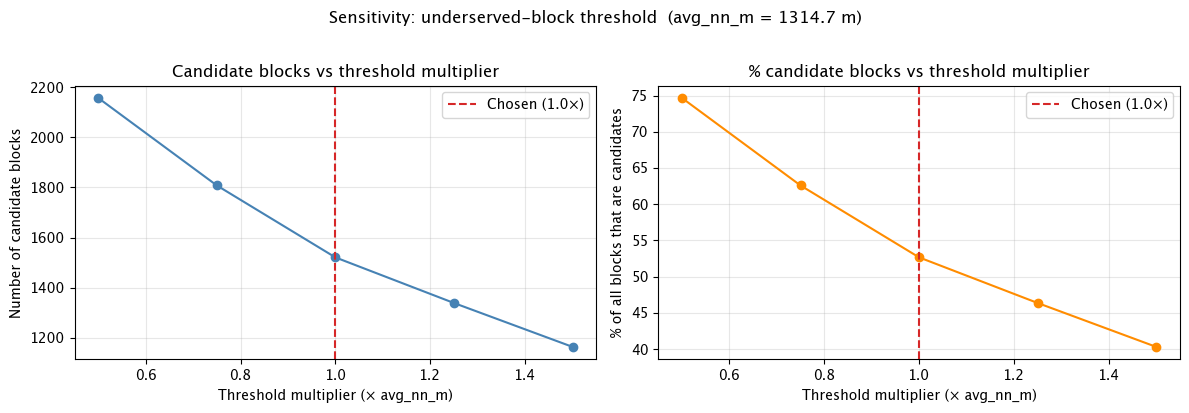

Saved: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/sensitivity_threshold.png

Interpretation: The empirical 1.0× threshold is the natural breakpoint
that mirrors existing-store spacing.  Larger multipliers over-restrict
candidates; smaller ones include blocks already adequately served.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SENSITIVITY 1 — Underserved-block threshold multiplier
# Reviewer 3: "The threshold for underserved blocks (321.20 m) is not justified"
# We sweep multipliers of avg_nn_m and record candidate-block count & density.
# ─────────────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

threshold_multipliers = [0.50, 0.75, 1.00, 1.25, 1.50]
sens_threshold_rows = []

for mult in threshold_multipliers:
    thresh = avg_nn_m * mult
    n_candidates = int((gdf_nodos['distancia_red_m'] > thresh).sum())
    n_total = len(gdf_nodos)
    pct = 100.0 * n_candidates / n_total if n_total > 0 else 0.0
    sens_threshold_rows.append({
        'multiplier': mult,
        'threshold_m': round(thresh, 2),
        'n_candidates': n_candidates,
        'pct_candidates': round(pct, 2),
    })

df_sens_thresh = pd.DataFrame(sens_threshold_rows)
print(df_sens_thresh.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_sens_thresh['multiplier'], df_sens_thresh['n_candidates'], marker='o', color='steelblue')
axes[0].axvline(1.0, linestyle='--', color='tab:red', label='Chosen (1.0×)')
axes[0].set_xlabel('Threshold multiplier (× avg_nn_m)')
axes[0].set_ylabel('Number of candidate blocks')
axes[0].set_title('Candidate blocks vs threshold multiplier')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(df_sens_thresh['multiplier'], df_sens_thresh['pct_candidates'], marker='o', color='darkorange')
axes[1].axvline(1.0, linestyle='--', color='tab:red', label='Chosen (1.0×)')
axes[1].set_xlabel('Threshold multiplier (× avg_nn_m)')
axes[1].set_ylabel('% of all blocks that are candidates')
axes[1].set_title('% candidate blocks vs threshold multiplier')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(
    f'Sensitivity: underserved-block threshold  (avg_nn_m = {avg_nn_m:.1f} m)',
    fontsize=12, y=1.02
)
plt.tight_layout()
out = FIG_DIR / 'sensitivity_threshold.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out)
print()
print("Interpretation: The empirical 1.0× threshold is the natural breakpoint")
print("that mirrors existing-store spacing.  Larger multipliers over-restrict")
print("candidates; smaller ones include blocks already adequately served.")


  K= 6 → k*=20, silhouette=-0.4943, runtime=1975.9s
  K= 8 → k*=20, silhouette=-0.3802, runtime=771.4s
  K=10 → k*=14, silhouette=-0.3294, runtime=284.9s
  K=12 → k*=18, silhouette=-0.3660, runtime=45.2s
  K=15 → k*=18, silhouette=-0.3754, runtime=20.3s
  K=18 → k*=13, silhouette=-0.3526, runtime=24.0s
  K=20 → k*=16, silhouette=-0.3836, runtime=17.7s

 K  k_star  silhouette  runtime_s
 6      20     -0.4943     1975.9
 8      20     -0.3802      771.4
10      14     -0.3294      284.9
12      18     -0.3660       45.2
15      18     -0.3754       20.3
18      13     -0.3526       24.0
20      16     -0.3836       17.7


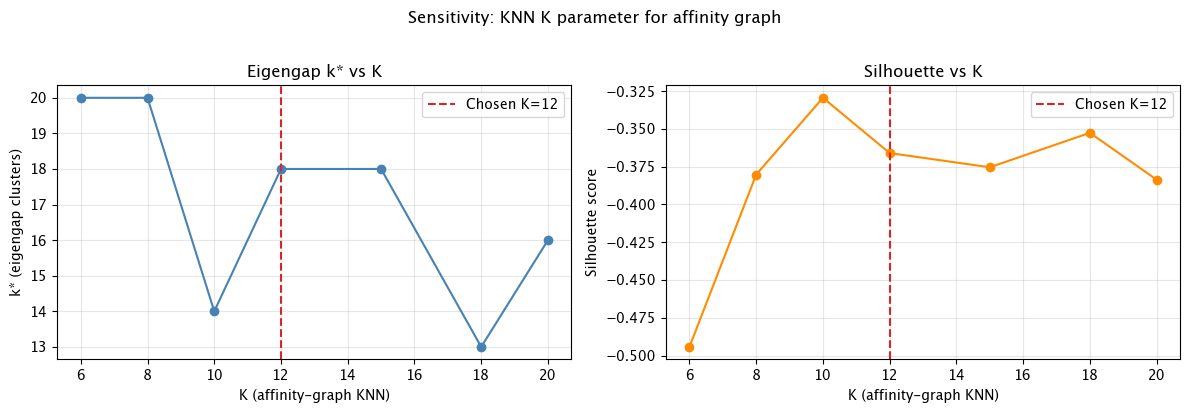

Saved: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/sensitivity_knn_k.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SENSITIVITY 2 — KNN affinity-graph K parameter
# Reviewer 3: "The K parameter in the k-NN algorithm is arbitrary"
# Sweep: rebuild affinity matrix for each K, compute eigengap-selected k*
# and silhouette score (fast: spectral embedding only, no re-solve).
# ─────────────────────────────────────────────────────────────────────────────
import time
from sklearn.cluster import SpectralClustering as _SC
from sklearn.metrics import silhouette_score as _sil
from scipy.sparse.csgraph import laplacian as _lap
from scipy.sparse.linalg import eigsh as _eigsh
from sklearn.neighbors import NearestNeighbors as _KNN

k_sweep = [6, 8, 10, 12, 15, 18, 20]
sens_knn_rows = []

_coords_xy = np.column_stack([gdf_nodos_utm.geometry.x.values, gdf_nodos_utm.geometry.y.values])
_graph_nodes_arr = gdf_nodos['graph_node'].to_numpy()

for K_val in k_sweep:
    t0 = time.time()
    _nn = _KNN(n_neighbors=K_val + 1, metric='euclidean')
    _nn.fit(_coords_xy)
    _, _idx = _nn.kneighbors(_coords_xy)

    _rows, _cols, _dvals = [], [], []
    _sp_cache_k = {}

    def _sp_k(a, b):
        key = (a, b) if a <= b else (b, a)
        if key in _sp_cache_k:
            return _sp_cache_k[key]
        if a == b:
            _sp_cache_k[key] = 0.0; return 0.0
        try:
            d = float(nx.shortest_path_length(G_proj, source=a, target=b, weight='length'))
        except nx.NetworkXNoPath:
            d = np.inf
        _sp_cache_k[key] = d; return d

    for i in range(len(_coords_xy)):
        for j in _idx[i, 1:]:
            if i >= j: continue
            d_ij = _sp_k(int(_graph_nodes_arr[i]), int(_graph_nodes_arr[j]))
            if np.isfinite(d_ij):
                _rows += [i, j]; _cols += [j, i]; _dvals += [d_ij, d_ij]

    if not _dvals:
        sens_knn_rows.append({'K': K_val, 'k_star': np.nan, 'silhouette': np.nan, 'runtime_s': np.nan})
        continue

    _dv = np.asarray(_dvals, float)
    _sigma_k = np.median(_dv[_dv > 0]) if np.any(_dv > 0) else 1.0
    _aff = np.exp(-(_dv**2) / (2.0 * _sigma_k**2))
    from scipy import sparse as _sp
    _W_k = _sp.coo_matrix((_aff, (_rows, _cols)), shape=(len(_coords_xy), len(_coords_xy))).tocsr()
    _W_k = _W_k.maximum(_W_k.T); _W_k.setdiag(1.0); _W_k.eliminate_zeros()

    _L_k = _lap(_W_k, normed=True)
    _k_eigs = min(MAX_K_EIGENGAP + 1, len(_coords_xy) - 1)
    _ev, _evec = _eigsh(_L_k, k=_k_eigs, which='SM',maxiter=100000)
    _order = np.argsort(_ev); _ev = _ev[_order]; _evec = _evec[:, _order]
    _k_cands = np.arange(2, min(MAX_K_EIGENGAP, len(_ev) - 1) + 1)
    _gaps = np.array([_ev[k] - _ev[k-1] for k in _k_cands])
    _k_star = int(_k_cands[np.argmax(_gaps)])

    # Silhouette on spectral embedding with k_star clusters
    _emb = _evec[:, 1:min(_k_star+1, _evec.shape[1])]
    _model_k = _SC(n_clusters=_k_star, affinity='precomputed',
                   assign_labels='kmeans', random_state=RANDOM_SEED, n_init=10)
    _labels_k = _model_k.fit_predict(_W_k.toarray())
    _sil_score = float(_sil(_emb, _labels_k, metric='euclidean')) if len(set(_labels_k)) > 1 else np.nan

    elapsed = time.time() - t0
    sens_knn_rows.append({'K': K_val, 'k_star': _k_star, 'silhouette': round(_sil_score, 4), 'runtime_s': round(elapsed, 1)})
    print(f"  K={K_val:2d} → k*={_k_star}, silhouette={_sil_score:.4f}, runtime={elapsed:.1f}s")

df_sens_knn = pd.DataFrame(sens_knn_rows)
print()
print(df_sens_knn.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(df_sens_knn['K'], df_sens_knn['k_star'], marker='o', color='steelblue')
axes[0].axvline(K_NEIGH_EUCLIDEAN, linestyle='--', color='tab:red', label=f'Chosen K={K_NEIGH_EUCLIDEAN}')
axes[0].set_xlabel('K (affinity-graph KNN)'); axes[0].set_ylabel('k* (eigengap clusters)')
axes[0].set_title('Eigengap k* vs K'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(df_sens_knn['K'], df_sens_knn['silhouette'], marker='o', color='darkorange')
axes[1].axvline(K_NEIGH_EUCLIDEAN, linestyle='--', color='tab:red', label=f'Chosen K={K_NEIGH_EUCLIDEAN}')
axes[1].set_xlabel('K (affinity-graph KNN)'); axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette vs K'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Sensitivity: KNN K parameter for affinity graph', fontsize=12, y=1.02)
plt.tight_layout()
out = FIG_DIR / 'sensitivity_knn_k.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out)


 beta  weight_cv  corr_with_pop  top_quartile_share
 0.00     1.3750         1.0000              0.1223
 0.10     1.3506         0.9972              0.1459
 0.15     1.3410         0.9935              0.1580
 0.20     1.3334         0.9879              0.1705
 0.25     1.3280         0.9804              0.1833
 0.35     1.3245         0.9591              0.2097
 0.50     1.3405         0.9099              0.2519
 1.00     1.6315         0.6248              0.4193


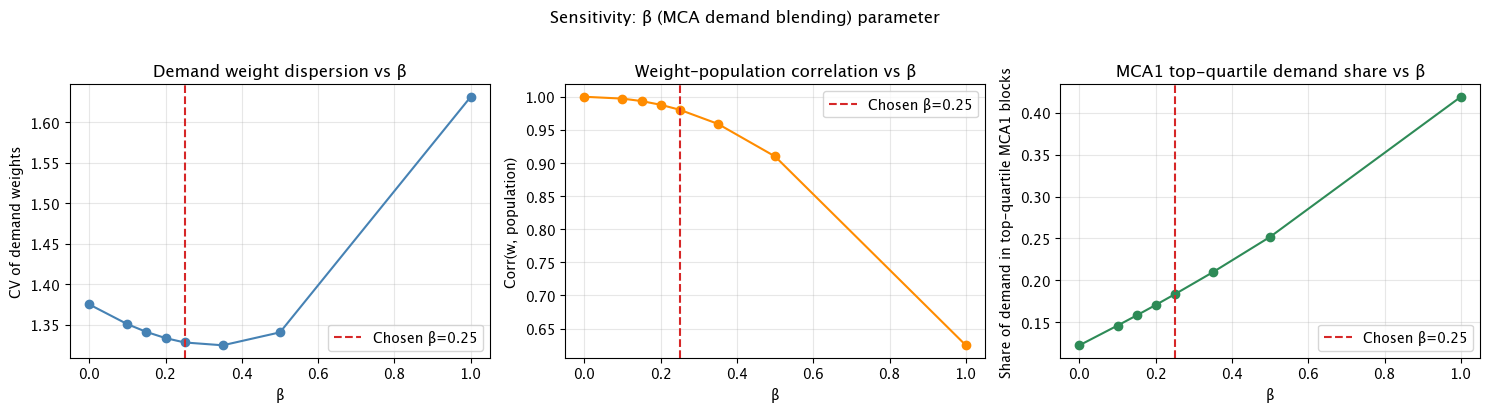

Saved: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/sensitivity_beta.png

Interpretation: β=0.25 keeps demand weights strongly correlated with
population (minimal distortion) while meaningfully redirecting effort
toward higher-MCA1 blocks.  Larger β over-concentrates on urban-quality
blocks and could starve lower-resource areas that need service most.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SENSITIVITY 3 — Beta (β) MCA demand-weight blending coefficient
# Reviewer 3: "Parameters (β=0.25, λ=5000) lack justification"
# Sweep: recompute demand weights only (no re-solve); record how the weight
# distribution shifts relative to pure population weighting (β=0).
# ─────────────────────────────────────────────────────────────────────────────
beta_sweep = [0.0, 0.10, 0.15, 0.20, 0.25, 0.35, 0.50, 1.0]
sens_beta_rows = []

_mca1 = data_condensed['MCA1'].astype(float)
_pop  = data_condensed['POBTOT'].astype(float)
_std  = float(_mca1.std(ddof=0)) if len(_mca1) > 1 else 1.0
_mca1_z = (_mca1 - float(_mca1.mean())) / (_std if _std > 0 else 1.0)

for _beta in beta_sweep:
    _w = (_pop * (1.0 + _beta * _mca1_z.fillna(0.0))).clip(lower=0.0)
    # Deviation from uniform (β=0) solution expressed as coefficient of variation
    _w0 = _pop.clip(lower=0.0)
    _corr_w_pop = float(np.corrcoef(_w.values, _pop.values)[0, 1]) if _pop.std() > 0 else 1.0
    _cv = float(_w.std() / _w.mean()) if float(_w.mean()) > 0 else 0.0
    # Fraction of demand weight going to top-quartile MCA1 blocks
    _q75 = float(_mca1_z.quantile(0.75))
    _top_frac = float(_w[_mca1_z >= _q75].sum() / _w.sum()) if _w.sum() > 0 else 0.0
    sens_beta_rows.append({
        'beta': _beta,
        'weight_cv': round(_cv, 4),
        'corr_with_pop': round(_corr_w_pop, 4),
        'top_quartile_share': round(_top_frac, 4),
    })

df_sens_beta = pd.DataFrame(sens_beta_rows)
print(df_sens_beta.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(df_sens_beta['beta'], df_sens_beta['weight_cv'], marker='o', color='steelblue')
axes[0].axvline(BETA, linestyle='--', color='tab:red', label=f'Chosen β={BETA}')
axes[0].set_xlabel('β'); axes[0].set_ylabel('CV of demand weights')
axes[0].set_title('Demand weight dispersion vs β'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(df_sens_beta['beta'], df_sens_beta['corr_with_pop'], marker='o', color='darkorange')
axes[1].axvline(BETA, linestyle='--', color='tab:red', label=f'Chosen β={BETA}')
axes[1].set_xlabel('β'); axes[1].set_ylabel('Corr(w, population)')
axes[1].set_title('Weight–population correlation vs β'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(df_sens_beta['beta'], df_sens_beta['top_quartile_share'], marker='o', color='seagreen')
axes[2].axvline(BETA, linestyle='--', color='tab:red', label=f'Chosen β={BETA}')
axes[2].set_xlabel('β'); axes[2].set_ylabel('Share of demand in top-quartile MCA1 blocks')
axes[2].set_title('MCA1 top-quartile demand share vs β'); axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle('Sensitivity: β (MCA demand blending) parameter', fontsize=12, y=1.02)
plt.tight_layout()
out = FIG_DIR / 'sensitivity_beta.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out)
print()
print(f"Interpretation: β={BETA} keeps demand weights strongly correlated with")
print("population (minimal distortion) while meaningfully redirecting effort")
print("toward higher-MCA1 blocks.  Larger β over-concentrates on urban-quality")
print("blocks and could starve lower-resource areas that need service most.")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# GRID SEARCH — Optimisation parameters (D_MAX × S_MIN × p_new × β)
# Addresses Reviewer 2 & 3: empirical justification for chosen parameters.
# Strategy: reuse pre-built p-median inputs (df_I, df_J, df_P, df_A,
# df_conflictos) and re-solve with modified weights / p_new values only.
# Full arc sets are rebuilt only when D_MAX changes.
# ─────────────────────────────────────────────────────────────────────────────
import itertools, time
import warnings

# Reduced grid (set FAST_GRID=False to run the full grid — slower)
FAST_GRID = True

if FAST_GRID:
    _dmax_vals   = [300, 366, 450]
    _smin_vals   = [200, 240, 300]
    _pnew_vals   = [5, 7, 9]
    _beta_vals   = [0.10, 0.25, 0.50]
else:
    _dmax_vals   = [250, 300, 366, 450, 550]
    _smin_vals   = [150, 200, 240, 300]
    _pnew_vals   = [5, 6, 7, 8, 9]
    _beta_vals   = [0.10, 0.20, 0.25, 0.35, 0.50]

_grid = list(itertools.product(_dmax_vals, _smin_vals, _pnew_vals, _beta_vals))
print(f"Grid size: {len(_grid)} combinations  (FAST_GRID={FAST_GRID})")

_grid_rows = []
_arc_cache = {}   # cache arc sets by (D_MAX, S_MIN)

for _dmax, _smin, _pnew, _beta in _grid:
    _t0 = time.time()

    # Rebuild arc sets only when (D_MAX, S_MIN) changes
    _arc_key = (_dmax, _smin)
    if _arc_key not in _arc_cache:
        try:
            _dI, _dE, _dJ, _dP, _dA, _dC, _p = build_pmedian_inputs_graph(
                data_condensed, G_proj,
                D_MAX=float(_dmax), S_MIN=float(_smin), beta=float(_beta),
                cluster_col='segmento'
            )
            _arc_cache[_arc_key] = (_dI, _dE, _dJ, _dP, _dA, _dC)
        except Exception as _e:
            _grid_rows.append({
                'D_MAX': _dmax, 'S_MIN': _smin, 'p_new': _pnew, 'beta': _beta,
                'coverage_rate': np.nan, 'w_mean_dist_m': np.nan,
                'n_covered': np.nan, 'runtime_s': np.nan, 'solver_status': f'BUILD_ERROR:{_e}'
            })
            continue

    _dI, _dE, _dJ, _dP, _dA, _dC = _arc_cache[_arc_key]

    # Recompute demand weights for this beta
    _dI_b = _dI.copy()
    _mca1_b = _dI_b['MCA1'].astype(float)
    _std_b  = float(_mca1_b.std(ddof=0)) if len(_mca1_b) > 1 else 1.0
    _z_b    = (_mca1_b - float(_mca1_b.mean())) / (_std_b if _std_b > 0 else 1.0)
    _dI_b['w'] = (_dI_b['POBTOT'].astype(float) * (1.0 + _beta * _z_b.fillna(0.0))).clip(lower=0.0)

    _j2p = dict(_dJ[['j','p']].astype(int).itertuples(index=False, name=None)) if len(_dJ) > 0 else {}
    _clusters = sorted(_dI_b['cluster_i'].dropna().astype(int).unique().tolist())

    _all_assign, _all_open = [], []
    _status_ok = True

    for _c in _clusters:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            _a, _o, _m, _s = solve_cluster_model(
                cluster_id=int(_c), df_I=_dI_b, df_J=_dJ, df_P=_dP,
                df_A=_dA, df_conflictos=_dC, j_to_p_map=_j2p,
                p_new_per_cluster=int(_pnew),
                penalty_uncovered=PENALTY_UNCOVERED,
                time_limit_sec=60,   # shorter limit for grid search
                solver_msg=False,
            )
        _all_assign.append(_a)
        if _s not in ('Optimal', 'Not Solved') and 'TIME' not in str(_s).upper():
            _status_ok = False

    _agg = pd.concat(_all_assign, ignore_index=True) if _all_assign else pd.DataFrame()
    if len(_agg) > 0 and 'uncovered' in _agg.columns:
        _cov = _agg[_agg['uncovered'] == 0].copy()
        _n_cov = int(len(_cov))
        _n_dem = int(len(_agg))
        _cov_rate = _n_cov / _n_dem if _n_dem > 0 else np.nan
        _wsum = float(_cov['w_i'].sum()) if 'w_i' in _cov.columns else 0.0
        _wmd  = float((_cov['dist_m'] * _cov['w_i']).sum() / _wsum) if _wsum > 0 else np.nan
    else:
        _n_cov, _n_dem, _cov_rate, _wmd = 0, 0, np.nan, np.nan

    _elapsed = round(time.time() - _t0, 2)
    _grid_rows.append({
        'D_MAX': _dmax, 'S_MIN': _smin, 'p_new': _pnew, 'beta': _beta,
        'coverage_rate': round(float(_cov_rate), 4) if _cov_rate is not None and not np.isnan(_cov_rate) else np.nan,
        'w_mean_dist_m': round(float(_wmd), 2) if _wmd is not None and not np.isnan(_wmd) else np.nan,
        'n_covered': int(_n_cov),
        'runtime_s': _elapsed,
        'solver_status': 'OK' if _status_ok else 'PARTIAL',
    })
    print(f"  D_MAX={_dmax}, S_MIN={_smin}, p_new={_pnew}, β={_beta} "
          f"→ cov={_cov_rate:.3f}, wmd={_wmd:.1f}m, t={_elapsed}s")

df_grid = pd.DataFrame(_grid_rows)
df_grid.to_csv(RESULTS_DIR / 'grid_search_results.csv', index=False)
print(f"\nGrid results saved → {RESULTS_DIR / 'grid_search_results.csv'}")
print(df_grid.sort_values('coverage_rate', ascending=False).head(10).to_string(index=False))


Grid size: 81 combinations  (FAST_GRID=True)
Arcs progress: 300/2093 source nodes
Arcs progress: 600/2093 source nodes
Arcs progress: 900/2093 source nodes
Arcs progress: 1200/2093 source nodes
Arcs progress: 1500/2093 source nodes
Arcs progress: 1800/2093 source nodes
Arcs progress: 2093/2093 source nodes
  D_MAX=300, S_MIN=200, p_new=5, β=0.1 → cov=0.136, wmd=166.9m, t=12.33s
  D_MAX=300, S_MIN=200, p_new=5, β=0.25 → cov=0.135, wmd=159.8m, t=12.18s
  D_MAX=300, S_MIN=200, p_new=5, β=0.5 → cov=0.130, wmd=152.7m, t=8.34s
  D_MAX=300, S_MIN=200, p_new=7, β=0.1 → cov=0.171, wmd=159.7m, t=8.55s
  D_MAX=300, S_MIN=200, p_new=7, β=0.25 → cov=0.175, wmd=158.9m, t=10.28s
  D_MAX=300, S_MIN=200, p_new=7, β=0.5 → cov=0.172, wmd=158.8m, t=8.99s
  D_MAX=300, S_MIN=200, p_new=9, β=0.1 → cov=0.200, wmd=161.1m, t=8.91s
  D_MAX=300, S_MIN=200, p_new=9, β=0.25 → cov=0.200, wmd=159.8m, t=9.03s
  D_MAX=300, S_MIN=200, p_new=9, β=0.5 → cov=0.201, wmd=161.3m, t=8.87s
Arcs progress: 300/2093 source nodes
A

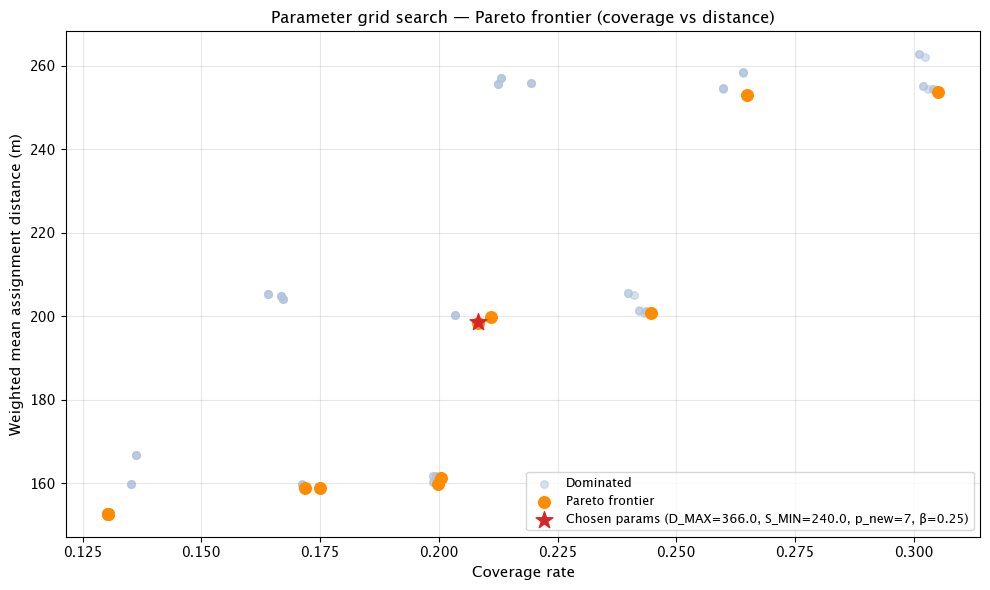

Saved: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/grid_search_pareto.png

Pareto-optimal combinations (12 of 81):
 D_MAX  S_MIN  p_new  beta  coverage_rate  w_mean_dist_m
   450    200      9  0.25         0.3052         253.69
   450    200      7  0.25         0.2648         253.09
   366    200      9  0.25         0.2447         200.72
   366    200      7  0.50         0.2109         199.93
   366    200      7  0.25         0.2083         198.36
   300    200      9  0.50         0.2005         161.27
   300    200      9  0.25         0.1998         159.85
   300    200      7  0.25         0.1749         158.92
   300    200      7  0.50         0.1719         158.85
   300    200      5  0.50         0.1303         152.70
   300    240      5  0.50         0.1303         152.70
   300    300      5  0.50         0.1303         152.70


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# PARETO FRONTIER — coverage vs weighted mean distance
# Highlights the parameter set that matches the chosen defaults.
# ─────────────────────────────────────────────────────────────────────────────
_gv = df_grid.dropna(subset=['coverage_rate', 'w_mean_dist_m']).copy()

# Pareto dominance: a point dominates if it has HIGHER coverage AND LOWER distance
def _is_pareto(df):
    dominated = np.zeros(len(df), dtype=bool)
    vals = df[['coverage_rate', 'w_mean_dist_m']].values
    for i in range(len(vals)):
        for j in range(len(vals)):
            if i == j: continue
            # j dominates i if: coverage_j >= coverage_i AND dist_j <= dist_i (strict on at least one)
            if (vals[j,0] >= vals[i,0] and vals[j,1] <= vals[i,1] and
                    (vals[j,0] > vals[i,0] or vals[j,1] < vals[i,1])):
                dominated[i] = True; break
    return ~dominated

_gv = _gv.reset_index(drop=True)
_gv['is_pareto'] = _is_pareto(_gv)

# Mark the row closest to chosen defaults
_is_chosen = (
    (_gv['D_MAX'] == D_MAX) &
    (_gv['S_MIN'] == S_MIN) &
    (_gv['p_new'] == P_NEW_PER_CLUSTER) &
    (_gv['beta'].round(2) == round(BETA, 2))
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(_gv.loc[~_gv['is_pareto'], 'coverage_rate'],
           _gv.loc[~_gv['is_pareto'], 'w_mean_dist_m'],
           c='lightsteelblue', alpha=0.5, s=30, label='Dominated')
ax.scatter(_gv.loc[_gv['is_pareto'], 'coverage_rate'],
           _gv.loc[_gv['is_pareto'], 'w_mean_dist_m'],
           c='darkorange', s=70, zorder=3, label='Pareto frontier')
if _is_chosen.any():
    ax.scatter(_gv.loc[_is_chosen, 'coverage_rate'],
               _gv.loc[_is_chosen, 'w_mean_dist_m'],
               c='tab:red', s=160, marker='*', zorder=5,
               label=f'Chosen params (D_MAX={D_MAX}, S_MIN={S_MIN}, p_new={P_NEW_PER_CLUSTER}, β={BETA})')

ax.set_xlabel('Coverage rate', fontsize=11)
ax.set_ylabel('Weighted mean assignment distance (m)', fontsize=11)
ax.set_title('Parameter grid search — Pareto frontier (coverage vs distance)', fontsize=12)
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout()
out = FIG_DIR / 'grid_search_pareto.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out)
print(f"\nPareto-optimal combinations ({_gv['is_pareto'].sum()} of {len(_gv)}):")
print(_gv[_gv['is_pareto']].sort_values('coverage_rate', ascending=False)
      [['D_MAX','S_MIN','p_new','beta','coverage_rate','w_mean_dist_m']].to_string(index=False))


## Baseline Comparisons

Addresses **Reviewer 2 & 3**: "The pipeline is not compared with simpler alternatives (k-means or p-median without clustering)" and "No benchmarking against alternative clustering methods".

Four baselines are evaluated on identical data and demand weights:

| Baseline | Description |
|----------|-------------|
| **B1 — Global P-Median** | Single p-median over the full study area; no clustering |
| **B2 — K-Means + P-Median** | K-Means (k=6) in Euclidean space replaces spectral clustering |
| **B3 — Euclidean P-Median** | Full pipeline but straight-line distances replace road-network distances |
| **B4 — No MCA (β=0)** | Full pipeline with β=0 (pure population weighting; no MCA modifier) |

Results are compared to the proposed model on coverage rate and weighted mean assignment distance.


K-Means (4 clusters) cluster sizes:
{0: 1044, 1: 750, 2: 573, 3: 522}


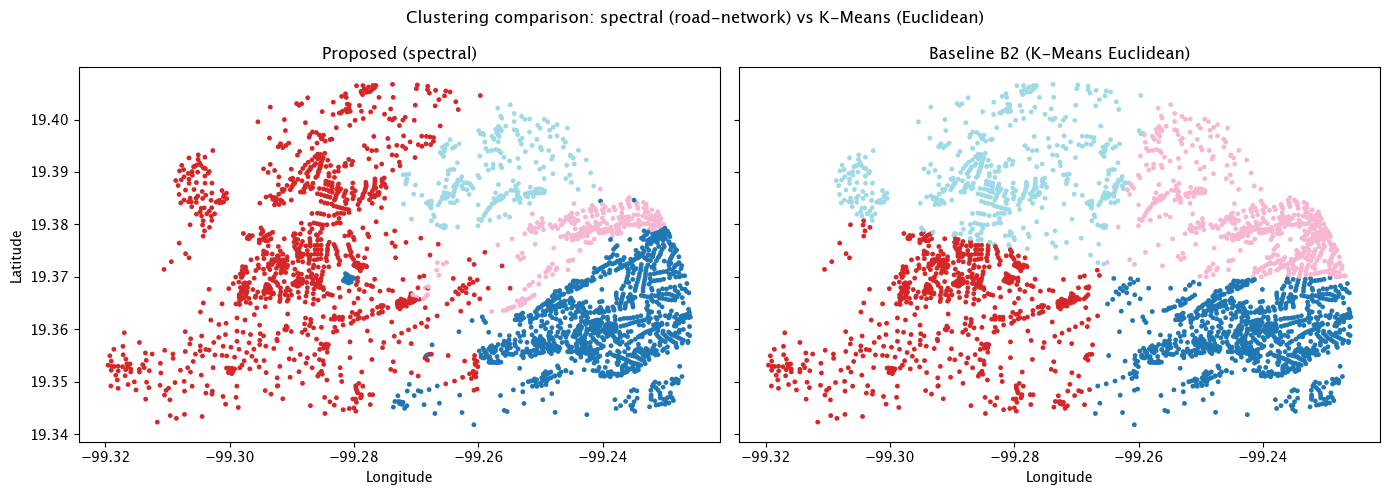

Saved: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/baseline_clustering_comparison.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BASELINE HELPER — K-Means clustering (Euclidean, k=6)
# Used by Baseline B2.
# ─────────────────────────────────────────────────────────────────────────────
from sklearn.cluster import KMeans

_n_clusters_baseline = int(manzanas_completas['segmento'].nunique())  # same k as proposed model
_coords_km = np.column_stack([gdf_nodos_utm.geometry.x.values, gdf_nodos_utm.geometry.y.values])

kmeans = KMeans(n_clusters=_n_clusters_baseline, random_state=RANDOM_SEED, n_init=20)
_labels_km = kmeans.fit_predict(_coords_km)

# Relabel by descending cluster size (consistent with proposed model convention)
_km_series = pd.Series(_labels_km)
_km_counts = _km_series.value_counts().sort_values(ascending=False)
_km_map = {old: new for new, old in enumerate(_km_counts.index)}
labels_kmeans = _km_series.map(_km_map).astype(int).values

print(f"K-Means ({_n_clusters_baseline} clusters) cluster sizes:")
print(pd.Series(labels_kmeans).value_counts().sort_index().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
axes[0].scatter(manzanas_completas['lon'], manzanas_completas['lat'],
                c=manzanas_completas['segmento'], cmap='tab20', s=6)
axes[0].set_title('Proposed (spectral)'); axes[0].set_xlabel('Longitude'); axes[0].set_ylabel('Latitude')

axes[1].scatter(manzanas_completas['lon'], manzanas_completas['lat'],
                c=labels_kmeans, cmap='tab20', s=6)
axes[1].set_title('Baseline B2 (K-Means Euclidean)'); axes[1].set_xlabel('Longitude')

plt.suptitle('Clustering comparison: spectral (road-network) vs K-Means (Euclidean)', fontsize=12)
plt.tight_layout()
out = FIG_DIR / 'baseline_clustering_comparison.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BASELINES B1–B4 — Solve and collect metrics
# Addresses Reviewer 2 & 3: comparison with simpler alternatives.
# ─────────────────────────────────────────────────────────────────────────────
import warnings

def _run_model(label, df_cond, G_graph, cluster_labels, dmax, smin, beta,
               p_new_fixed, p_new_total, p_new_mode, penalty, time_limit):
    """Helper: build inputs, run clustered p-median, return metric dict."""
    _dc = df_cond.copy()
    _dc['segmento'] = cluster_labels

    try:
        _dI, _dE, _dJ, _dP, _dA, _dC, _p = build_pmedian_inputs_graph(
            _dc, G_graph, D_MAX=dmax, S_MIN=smin, beta=beta, cluster_col='segmento'
        )
    except Exception as e:
        return {'model': label, 'coverage_rate': np.nan, 'w_mean_dist_m': np.nan,
                'n_covered': np.nan, 'runtime_s': np.nan, 'solver_status': f'BUILD_ERR:{e}',
                'n_openings': np.nan, 'n_demands': np.nan}

    _pnew_map = compute_pnew_per_cluster(
        _dI,
        sorted(_dI['cluster_i'].dropna().astype(int).unique().tolist()),
        mode=p_new_mode, pnew_fixed=p_new_fixed, pnew_total=p_new_total
    )
    _j2p = dict(_dJ[['j','p']].astype(int).itertuples(index=False, name=None)) if len(_dJ) > 0 else {}
    _clusters = sorted(_dI['cluster_i'].dropna().astype(int).unique().tolist())

    _all_assign = []
    _t0 = __import__('time').time()
    for _c in _clusters:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            _a, _, _, _ = solve_cluster_model(
                cluster_id=int(_c), df_I=_dI, df_J=_dJ, df_P=_dP,
                df_A=_dA, df_conflictos=_dC, j_to_p_map=_j2p,
                p_new_per_cluster=_pnew_map.get(int(_c), p_new_fixed),
                penalty_uncovered=penalty, time_limit_sec=time_limit, solver_msg=False
            )
        _all_assign.append(_a)

    _agg = pd.concat(_all_assign, ignore_index=True) if _all_assign else pd.DataFrame()
    _elapsed = round(__import__('time').time() - _t0, 2)

    if len(_agg) == 0 or 'uncovered' not in _agg.columns:
        return {'model': label, 'coverage_rate': np.nan, 'w_mean_dist_m': np.nan,
                'n_covered': 0, 'runtime_s': _elapsed, 'solver_status': 'EMPTY',
                'n_openings': 0, 'n_demands': 0}

    _cov = _agg[_agg['uncovered'] == 0].copy()
    _n_cov = int(len(_cov)); _n_dem = int(len(_agg))
    _cov_rate = _n_cov / _n_dem if _n_dem > 0 else np.nan
    _wsum = float(_cov['w_i'].sum()) if 'w_i' in _cov.columns else 0.0
    _wmd  = float((_cov['dist_m'] * _cov['w_i']).sum() / _wsum) if _wsum > 0 else np.nan
    _n_open = sum(_pnew_map.values())

    return {'model': label, 'coverage_rate': round(float(_cov_rate), 4),
            'w_mean_dist_m': round(float(_wmd), 2) if not np.isnan(_wmd) else np.nan,
            'n_covered': _n_cov, 'runtime_s': _elapsed, 'solver_status': 'OK',
            'n_openings': _n_open, 'n_demands': _n_dem}


# ── Proposed model (from main pipeline run) ───────────────────────────────────
_proposed_labels = data_condensed['segmento'].astype(int).values

_proposed_cov_rate = float(metrics_global['pct_covered_total'].iloc[0])
_proposed_wmd = float(metrics_global['w_mean_dist_m_total'].iloc[0])
_proposed_n_cov = int(metrics_global['covered_total'].iloc[0])
_proposed_n_dem = int(metrics_global['n_demands_total'].iloc[0])
_proposed_n_open = int(metrics_global['opened_total'].iloc[0])

result_proposed = {
    'model': 'Proposed (spectral + MCA)',
    'coverage_rate': round(_proposed_cov_rate, 4),
    'w_mean_dist_m': round(_proposed_wmd, 2),
    'n_covered': _proposed_n_cov,
    'runtime_s': np.nan,
    'solver_status': 'OK',
    'n_openings': _proposed_n_open,
    'n_demands': _proposed_n_dem,
}
print("Proposed model metrics loaded from main run.")

# ── B1: Global p-median (single cluster = all nodes) ─────────────────────────
print("\nRunning B1: Global p-median (no clustering) ...")
_all_one_label = np.zeros(len(data_condensed), dtype=int)
result_B1 = _run_model(
    'B1: Global P-Median (no clustering)',
    data_condensed, G_proj, _all_one_label,
    dmax=D_MAX, smin=S_MIN, beta=BETA,
    p_new_fixed=P_NEW_TOTAL, p_new_total=P_NEW_TOTAL, p_new_mode='fixed',
    penalty=PENALTY_UNCOVERED, time_limit=TIME_LIMIT_SEC
)
print(f"  → coverage={result_B1['coverage_rate']}, wmd={result_B1['w_mean_dist_m']}m, t={result_B1['runtime_s']}s")

# ── B2: K-Means clustering + p-median ────────────────────────────────────────
print("\nRunning B2: K-Means + p-median ...")
result_B2 = _run_model(
    'B2: K-Means + P-Median',
    data_condensed, G_proj, labels_kmeans,
    dmax=D_MAX, smin=S_MIN, beta=BETA,
    p_new_fixed=P_NEW_PER_CLUSTER, p_new_total=P_NEW_TOTAL, p_new_mode=P_NEW_MODE,
    penalty=PENALTY_UNCOVERED, time_limit=TIME_LIMIT_SEC
)
print(f"  → coverage={result_B2['coverage_rate']}, wmd={result_B2['w_mean_dist_m']}m, t={result_B2['runtime_s']}s")

# ── B3: Euclidean distances (straight-line, same spectral clusters) ───────────
print("\nRunning B3: Euclidean distances (road-network replaced by straight-line) ...")

class _EuclideanGraph:
    """Minimal graph-like object whose shortest_path_length uses Euclidean distance."""
    pass

def _euclidean_build_inputs(df_plot, D_MAX=366.0, S_MIN=240.0, beta=0.25, cluster_col='segmento', proj_epsg=32614):
    """Variant of build_pmedian_inputs_graph using Euclidean distances (in meters, projected CRS)."""
    from collections import defaultdict
    import geopandas as gpd
    from shapely.geometry import Point

    df = df_plot.copy().reset_index(drop=True)
    df['node_id'] = pd.to_numeric(df['node_id'], errors='coerce').astype('Int64')
    df['lat']     = pd.to_numeric(df['lat'], errors='coerce')
    df['lon']     = pd.to_numeric(df['lon'], errors='coerce')
    df['POBTOT']  = pd.to_numeric(df['POBTOT'], errors='coerce').fillna(0.0)
    df['MCA1']    = pd.to_numeric(df['MCA1'], errors='coerce').fillna(0.0)
    df['oxxo_presente'] = pd.to_numeric(df['oxxo_presente'], errors='coerce').fillna(0).astype(int)
    df['es_candidato']  = df['es_candidato'].astype(bool)
    df[cluster_col]     = pd.to_numeric(df[cluster_col], errors='coerce').fillna(-1).astype(int)
    df = df.dropna(subset=['node_id','lat','lon']).copy()
    df['node_id'] = df['node_id'].astype(int)

    # Project to metric CRS for Euclidean distances in meters
    gdf_proj = gpd.GeoDataFrame(df.copy(),
                                 geometry=gpd.points_from_xy(df['lon'], df['lat']),
                                 crs='EPSG:4326').to_crs(epsg=proj_epsg)
    df['x_m'] = gdf_proj.geometry.x.values
    df['y_m'] = gdf_proj.geometry.y.values

    df_I = df[df['POBTOT'] > 0].copy()
    df_I = df_I.rename(columns={cluster_col: 'cluster_i'})
    df_I['i'] = np.arange(len(df_I), dtype=int)
    _mca1 = df_I['MCA1'].astype(float)
    _std  = float(_mca1.std(ddof=0)) if len(_mca1) > 1 else 1.0
    _z    = (_mca1 - float(_mca1.mean())) / (_std if _std > 0 else 1.0)
    df_I['w'] = (df_I['POBTOT'].astype(float) * (1.0 + beta * _z.fillna(0.0))).clip(lower=0.0)

    df_E = df[df['oxxo_presente'] > 0].copy()
    df_E = df_E.rename(columns={cluster_col: 'cluster_p'})
    df_E['p'] = np.arange(len(df_E), dtype=int)
    df_E['es_existente'] = True

    df_J_raw = df[(df['oxxo_presente'] == 0) & (df['es_candidato'])].copy()
    df_J_raw = df_J_raw.rename(columns={cluster_col: 'cluster_p'})

    # Filter candidates by Euclidean distance to existing stores
    if len(df_E) > 0 and len(df_J_raw) > 0:
        _ex_coords = df_E[['x_m','y_m']].values
        _ca_coords = df_J_raw[['x_m','y_m']].values
        _min_d_to_E = np.min(
            np.sqrt(((_ca_coords[:,0:1] - _ex_coords[:,0])**2 + (_ca_coords[:,1:2] - _ex_coords[:,1])**2)),
            axis=1
        )
        df_J = df_J_raw[_min_d_to_E >= S_MIN].copy().reset_index(drop=True)
    else:
        df_J = df_J_raw.copy().reset_index(drop=True)

    df_J['j'] = np.arange(len(df_J), dtype=int)
    df_J['p'] = np.arange(len(df_E), len(df_E)+len(df_J), dtype=int)
    df_J['es_existente'] = False

    colsP = ['p','node_id','x_m','y_m','lat','lon','cluster_p','es_existente']
    for _c in colsP:
        if _c not in df_E.columns: df_E[_c] = np.nan
        if _c not in df_J.columns: df_J[_c] = np.nan
    df_P_e = pd.concat([df_E[colsP], df_J[colsP]], ignore_index=True)

    # Build arcs using Euclidean distance <= D_MAX
    _p_coords = df_P_e[['x_m','y_m']].values
    _p_ids    = df_P_e['p'].astype(int).values
    _i_coords = df_I[['x_m','y_m']].values
    _i_ids    = df_I['i'].astype(int).values

    arc_rows = []
    for _ii, (_xi, _yi) in enumerate(_i_coords):
        _dists = np.sqrt((_p_coords[:,0]-_xi)**2 + (_p_coords[:,1]-_yi)**2)
        _within = np.where(_dists <= D_MAX)[0]
        for _pi in _within:
            arc_rows.append((int(_i_ids[_ii]), int(_p_ids[_pi]), float(_dists[_pi])))

    df_A_e = pd.DataFrame(arc_rows, columns=['i','p','dist_m'])
    if len(df_A_e) > 0:
        df_A_e = df_A_e.groupby(['i','p'], as_index=False)['dist_m'].min().reset_index(drop=True)

    # Conflict pairs (Euclidean)
    conflict_rows = []
    if len(df_J) > 1:
        _j_coords = df_J[['x_m','y_m']].values
        _j_ids = df_J['j'].astype(int).values
        for _jj in range(len(df_J)):
            for _kk in range(_jj+1, len(df_J)):
                _d = float(np.sqrt((_j_coords[_jj,0]-_j_coords[_kk,0])**2 + (_j_coords[_jj,1]-_j_coords[_kk,1])**2))
                if _d < S_MIN:
                    conflict_rows.append((int(_j_ids[_jj]), int(_j_ids[_kk]), _d))
    df_C_e = pd.DataFrame(conflict_rows, columns=['j','k','dist_m'])

    # Add dummy graph_node column so solve_cluster_model doesn't break
    df_I['graph_node'] = df_I['node_id']
    df_P_e['graph_node'] = df_P_e['node_id']

    return df_I.reset_index(drop=True), df_E.reset_index(drop=True), df_J.reset_index(drop=True), df_P_e, df_A_e, df_C_e

_dc_b3 = data_condensed.copy()
_dc_b3['segmento'] = _proposed_labels

try:
    _dI3, _dE3, _dJ3, _dP3, _dA3, _dC3 = _euclidean_build_inputs(
        _dc_b3, D_MAX=D_MAX, S_MIN=S_MIN, beta=BETA, cluster_col='segmento', proj_epsg=PROJ_EPSG
    )
    _pnew3 = compute_pnew_per_cluster(_dI3,
        sorted(_dI3['cluster_i'].dropna().astype(int).unique().tolist()),
        mode=P_NEW_MODE, pnew_fixed=P_NEW_PER_CLUSTER, pnew_total=P_NEW_TOTAL)
    _j2p3 = dict(_dJ3[['j','p']].astype(int).itertuples(index=False, name=None)) if len(_dJ3) > 0 else {}
    _all3, _t03 = [], __import__('time').time()
    for _c3 in sorted(_dI3['cluster_i'].dropna().astype(int).unique()):
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            _a3, _, _, _ = solve_cluster_model(
                int(_c3), _dI3, _dJ3, _dP3, _dA3, _dC3, _j2p3,
                _pnew3.get(int(_c3), P_NEW_PER_CLUSTER), PENALTY_UNCOVERED, TIME_LIMIT_SEC, False)
        _all3.append(_a3)
    _agg3 = pd.concat(_all3, ignore_index=True) if _all3 else pd.DataFrame()
    _elapsed3 = round(__import__('time').time() - _t03, 2)
    if len(_agg3) > 0 and 'uncovered' in _agg3.columns:
        _cov3 = _agg3[_agg3['uncovered']==0].copy()
        _cr3 = len(_cov3)/len(_agg3)
        _ws3 = float(_cov3['w_i'].sum())
        _wmd3 = float((_cov3['dist_m']*_cov3['w_i']).sum()/_ws3) if _ws3 > 0 else np.nan
        result_B3 = {'model': 'B3: Euclidean distances',
                     'coverage_rate': round(_cr3,4), 'w_mean_dist_m': round(_wmd3,2) if not np.isnan(_wmd3) else np.nan,
                     'n_covered': int(len(_cov3)), 'runtime_s': _elapsed3, 'solver_status': 'OK',
                     'n_openings': sum(_pnew3.values()), 'n_demands': int(len(_agg3))}
    else:
        result_B3 = {'model': 'B3: Euclidean distances', 'coverage_rate': np.nan, 'w_mean_dist_m': np.nan,
                     'n_covered': 0, 'runtime_s': _elapsed3, 'solver_status': 'EMPTY', 'n_openings': 0, 'n_demands': 0}
except Exception as _e3:
    result_B3 = {'model': 'B3: Euclidean distances', 'coverage_rate': np.nan, 'w_mean_dist_m': np.nan,
                 'n_covered': np.nan, 'runtime_s': np.nan, 'solver_status': f'ERROR:{_e3}', 'n_openings': np.nan, 'n_demands': np.nan}
print(f"B3 → coverage={result_B3['coverage_rate']}, wmd={result_B3['w_mean_dist_m']}m, t={result_B3['runtime_s']}s")

# ── B4: No MCA weighting (β = 0) ─────────────────────────────────────────────
print("\nRunning B4: β=0 (pure population weighting, no MCA modifier) ...")
result_B4 = _run_model(
    'B4: No MCA (β=0)',
    data_condensed, G_proj, _proposed_labels,
    dmax=D_MAX, smin=S_MIN, beta=0.0,
    p_new_fixed=P_NEW_PER_CLUSTER, p_new_total=P_NEW_TOTAL, p_new_mode=P_NEW_MODE,
    penalty=PENALTY_UNCOVERED, time_limit=TIME_LIMIT_SEC
)
print(f"B4 → coverage={result_B4['coverage_rate']}, wmd={result_B4['w_mean_dist_m']}m, t={result_B4['runtime_s']}s")

# ── Compile comparison table ──────────────────────────────────────────────────
df_baselines = pd.DataFrame([result_proposed, result_B1, result_B2, result_B3, result_B4])
df_baselines['coverage_pct'] = (df_baselines['coverage_rate'] * 100).round(2)
df_baselines.to_csv(RESULTS_DIR / 'baseline_comparison.csv', index=False)
print("\n=== Baseline comparison table ===")
print(df_baselines[['model','coverage_pct','w_mean_dist_m','n_covered','n_openings','runtime_s','solver_status']].to_string(index=False))
print(f"\nSaved → {RESULTS_DIR / 'baseline_comparison.csv'}")


Proposed model metrics loaded from main run.

Running B1: Global p-median (no clustering) ...
Arcs progress: 300/2093 source nodes
Arcs progress: 600/2093 source nodes
Arcs progress: 900/2093 source nodes
Arcs progress: 1200/2093 source nodes
Arcs progress: 1500/2093 source nodes
Arcs progress: 1800/2093 source nodes
Arcs progress: 2093/2093 source nodes
  → coverage=0.3238, wmd=203.83m, t=8.93s

Running B2: K-Means + p-median ...
Arcs progress: 300/2093 source nodes
Arcs progress: 600/2093 source nodes
Arcs progress: 900/2093 source nodes
Arcs progress: 1200/2093 source nodes
Arcs progress: 1500/2093 source nodes
Arcs progress: 1800/2093 source nodes
Arcs progress: 2093/2093 source nodes
  → coverage=0.254, wmd=208.58m, t=12.27s

Running B3: Euclidean distances (road-network replaced by straight-line) ...
B3 → coverage=0.3747, wmd=225.0m, t=21.9s

Running B4: β=0 (pure population weighting, no MCA modifier) ...
Arcs progress: 300/2093 source nodes
Arcs progress: 600/2093 source nodes


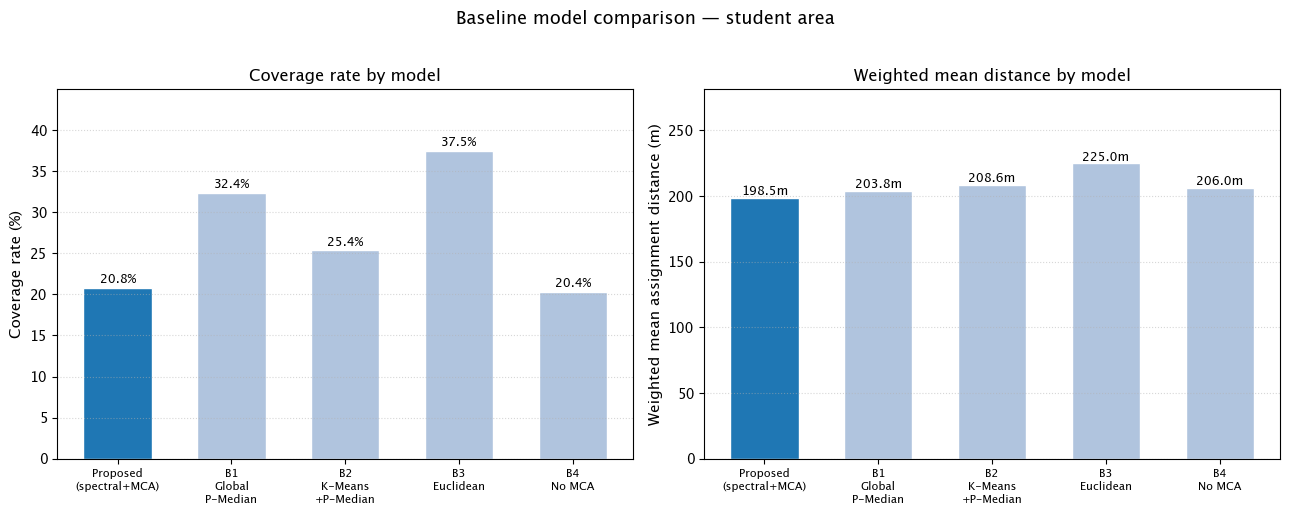

Saved: /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/figures/baseline_comparison_chart.png


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# BASELINE COMPARISON CHARTS
# ─────────────────────────────────────────────────────────────────────────────
_bl = df_baselines.copy()
_bl['short_label'] = _bl['model'].str.replace('Proposed', 'Proposed').str.split(':').str[-1].str.strip()
_bl['short_label'] = ['Proposed\n(spectral+MCA)', 'B1\nGlobal\nP-Median',
                       'B2\nK-Means\n+P-Median', 'B3\nEuclidean', 'B4\nNo MCA'][:len(_bl)]

_colors = ['tab:blue' if 'Proposed' in m else 'lightsteelblue' for m in _bl['model']]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Coverage
axes[0].bar(_bl['short_label'], _bl['coverage_pct'], color=_colors, edgecolor='white', width=0.6)
for i, (v, lbl) in enumerate(zip(_bl['coverage_pct'], _bl['short_label'])):
    if pd.notna(v):
        axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)
axes[0].set_ylabel('Coverage rate (%)', fontsize=11)
axes[0].set_title('Coverage rate by model', fontsize=12)
axes[0].set_ylim(0, min(100, (_bl['coverage_pct'].max(skipna=True) or 50) * 1.2))
axes[0].grid(axis='y', linestyle=':', alpha=0.5)

# Weighted mean distance
axes[1].bar(_bl['short_label'], _bl['w_mean_dist_m'], color=_colors, edgecolor='white', width=0.6)
for i, v in enumerate(_bl['w_mean_dist_m']):
    if pd.notna(v):
        axes[1].text(i, v + 0.5, f'{v:.1f}m', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Weighted mean assignment distance (m)', fontsize=11)
axes[1].set_title('Weighted mean distance by model', fontsize=12)
_wmd_max = _bl['w_mean_dist_m'].max(skipna=True) or 300
axes[1].set_ylim(0, _wmd_max * 1.25)
axes[1].grid(axis='y', linestyle=':', alpha=0.5)

for ax in axes:
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Baseline model comparison — student area', fontsize=13, y=1.02)
plt.tight_layout()
out = FIG_DIR / 'baseline_comparison_chart.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out)


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY METRICS — saved as JSON for cross-experiment comparison notebook
# Schema is fixed so the future comparison notebook can load all experiments
# with a simple loop: for exp in ['student','industrial','city']: load(...)
# ─────────────────────────────────────────────────────────────────────────────
import json, platform, subprocess
from datetime import datetime

def _get_git_hash():
    try:
        return subprocess.check_output(['git','rev-parse','HEAD'], stderr=subprocess.DEVNULL).decode().strip()
    except Exception:
        return 'N/A'

def _pkg_version(name):
    try:
        import importlib.metadata as _m
        return _m.version(name)
    except Exception:
        return 'N/A'

_cluster_sizes = manzanas_completas['segmento'].value_counts().sort_index().tolist()
_cluster_cov = metrics_por_cluster[['cluster','pct_covered']].set_index('cluster')['pct_covered'].to_dict()

# Weighted coverage per cluster from main run
_wcov_rows = (
    asignaciones_global
    .groupby('cluster_i')
    .apply(lambda g: float(g.loc[g['uncovered']==0,'w_i'].sum() / max(g['w_i'].sum(), 1e-9)))
    .to_dict()
)

_summary = {
    "experiment": EXPERIMENT,
    "label": cfg['label'],
    "run_timestamp": datetime.now().isoformat(timespec='seconds'),
    "git_hash": _get_git_hash(),
    "python_version": platform.python_version(),
    "library_versions": {
        "osmnx": _pkg_version('osmnx'),
        "geopandas": _pkg_version('geopandas'),
        "scikit_learn": _pkg_version('scikit-learn'),
        "pulp": _pkg_version('pulp'),
        "prince": _pkg_version('prince'),
        "numpy": _pkg_version('numpy'),
        "pandas": _pkg_version('pandas'),
    },
    "study_area": {
        "center_lat": cfg['center_lat'],
        "center_lon": cfg['center_lon'],
        "radius_km": cfg['radius_km'],
    },
    "instance": {
        "n_census_blocks": int(len(manzanas_completas)),
        "n_existing_stores": int(len(oxxos_dentro_5km)),
        "n_active_demand_nodes": int((manzanas_completas['POBTOT'] > 0).sum()),
        "n_candidate_blocks": int(manzanas_completas['es_candidato'].sum()),
        "n_clusters": int(manzanas_completas['segmento'].nunique()),
        "cluster_sizes": [int(x) for x in _cluster_sizes],
    },
    "results": {
        "n_new_openings": int(metrics_global['opened_total'].iloc[0]),
        "n_covered_demand_nodes": int(metrics_global['covered_total'].iloc[0]),
        "n_demands_total": int(metrics_global['n_demands_total'].iloc[0]),
        "coverage_rate": float(round(metrics_global['pct_covered_total'].iloc[0], 6)),
        "unweighted_mean_distance_m": float(round(metrics_global['mean_dist_m_total'].iloc[0], 4)),
        "weighted_mean_distance_m": float(round(metrics_global['w_mean_dist_m_total'].iloc[0], 4)),
        "cluster_coverage_rates": {str(k): float(round(v,4)) for k,v in _cluster_cov.items()},
        "cluster_weighted_coverage_rates": {str(k): float(round(v,4)) for k,v in _wcov_rows.items()},
    },
    "mca": {
        "dim1_corrected_inertia": float(round(gc_explained[0], 6)) if 'gc_explained' in dir() and len(gc_explained) > 0 else None,
        "dim2_corrected_inertia": float(round(gc_explained[1], 6)) if 'gc_explained' in dir() and len(gc_explained) > 1 else None,
    },
    "params_used": {
        "D_MAX": D_MAX, "S_MIN": S_MIN, "BETA": BETA,
        "P_NEW_MODE": P_NEW_MODE, "P_NEW_PER_CLUSTER": P_NEW_PER_CLUSTER,
        "P_NEW_TOTAL": P_NEW_TOTAL, "PENALTY_UNCOVERED": PENALTY_UNCOVERED,
        "K_NEIGH_EUCLIDEAN": K_NEIGH_EUCLIDEAN, "MIN_CLUSTER_SIZE": MIN_CLUSTER_SIZE,
        "RANDOM_SEED": RANDOM_SEED,
    },
    "baseline_comparison": df_baselines[
        ['model','coverage_rate','w_mean_dist_m','n_covered','n_openings','solver_status']
    ].to_dict(orient='records') if 'df_baselines' in dir() else [],
    "sensitivity_summary": {
        "threshold_multiplier_chosen": 1.0,
        "knn_k_chosen": K_NEIGH_EUCLIDEAN,
        "beta_chosen": BETA,
        "grid_search_n_combinations": int(len(df_grid)) if 'df_grid' in dir() else 0,
        "grid_search_pareto_n": int(_gv['is_pareto'].sum()) if '_gv' in dir() else 0,
    },
}

_out_json = RESULTS_DIR / 'summary_metrics.json'
with open(_out_json, 'w') as _f:
    json.dump(_summary, _f, indent=2, default=str)

print(f"Summary metrics saved → {_out_json}")
print(json.dumps({k: _summary[k] for k in ['experiment','label','results','params_used']}, indent=2, default=str))


Summary metrics saved → /Users/marielalvarez/Downloads/localizacion_sucursales/CLAIO2026/experimentos/industrial/outputs/tables/resultados_clusters/summary_metrics.json
{
  "experiment": "student",
  "label": "Student Area \u2014 Tecnol\u00f3gico de Monterrey",
  "results": {
    "n_new_openings": 28,
    "n_covered_demand_nodes": 561,
    "n_demands_total": 2693,
    "coverage_rate": 0.208318,
    "unweighted_mean_distance_m": 212.9518,
    "weighted_mean_distance_m": 198.5186,
    "cluster_coverage_rates": {
      "0": 0.1683,
      "1": 0.2072,
      "2": 0.2408,
      "3": 0.3801
    },
    "cluster_weighted_coverage_rates": {
      "0": 0.198,
      "1": 0.2214,
      "2": 0.2241,
      "3": 0.4681
    }
  },
  "params_used": {
    "D_MAX": 366.0,
    "S_MIN": 240.0,
    "BETA": 0.25,
    "P_NEW_MODE": "fixed",
    "P_NEW_PER_CLUSTER": 7,
    "P_NEW_TOTAL": 42,
    "PENALTY_UNCOVERED": 5000.0,
    "K_NEIGH_EUCLIDEAN": 12,
    "MIN_CLUSTER_SIZE": 200,
    "RANDOM_SEED": 42
  }
}
